# Notebook 38 — BO-ready state-aware DC–AC policy optimization

## Goal

Convert the Day35 rule-based state-aware DC–AC policy family into a Bayesian-optimization-ready policy-evaluation problem.

Notebook 38 does **not** implement a full MPC controller and does **not** yet perform closed-loop experimental control. Its first goal is to define a clean evaluator contract:

```text
policy parameters θ
→ prescribed-current waveform
→ PyBaMM evaluation
→ timing / margin / microstate metrics
→ constraint verdict
→ scalar score for future Bayesian optimization
```

## Scientific context

After Day37, the project claim boundary is frozen:

- stable, positive, engineering-significant non-geometric terminal-Q acceleration is not supported under the audited Chen2020 / DFN / isothermal / prescribed-current framework;
- raw timing gain is mainly prescribed-current geometry;
- DC–AC still produces meaningful microstate and negative-electrode margin effects;
- the stronger project direction is admissible DC–AC waveform optimization, not proof of non-geometric terminal-Q acceleration.

Notebook 38 therefore treats DC–AC as a waveform-policy optimization problem under constraints.

## Policy parameterization

The first BO-ready policy class uses four decision variables:

| Parameter | Meaning |
|---|---|
| `early_ac_c` | AC amplitude in early / mid-low Q region |
| `mid_ac_c` | AC amplitude after derating |
| `qfrac_derate` | Q_ref fraction where AC amplitude is reduced |
| `qfrac_ac_off` | Q_ref fraction where AC is turned off |

Fixed settings in Day38A:

```text
DC = 0.3C
tau_factor = 1.5τ_set
parameter set = Chen2020
model = DFN
thermal = isothermal
```

## Initial seed policies

Day38A starts from Day35 candidates:

- `sched_v2_conservative`
- `sched_v3_early_derate`
- `sched_v5_low_stress`

and adds a small deterministic seed set for future BO initialization.

## Evaluator metrics

The evaluator should return:

### Timing

- `delta_t_raw_mean_s`
- `delta_t_geom_mean_s`
- `delta_t_resid_mean_s`
- `dt_resid_class`

### Negative-electrode margin

- `min_U_NE_mV`
- `fraction_time_below_0mV`
- `fraction_time_below_50mV`

### Microstate context

- `max_c_e_range_vs_DC`
- `surface_range_at_min_vs_DC`
- `abs_eta_n_at_min_vs_DC`

### Verdict

- hard constraint violation flag
- soft penalty metrics
- scalar screening score

## Interpretation boundary

- Day38A defines a BO-ready evaluator contract.
- It does not claim global optimality.
- It does not implement MPC.
- It does not evaluate thermal or aging admissibility.
- The score is a screening objective, not a physical law.
- Any future BO result must still be audited by timing decomposition, U_NE margin, and microstate context.

In [1]:
# Cell 1 — Imports, paths, and Day38 metadata（导入库、路径与Day38元数据）

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

warnings.filterwarnings("default")

REPO = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA_DIR = REPO / "data"
FIG_DIR = REPO / "figures"
DOCS_DIR = REPO / "docs"

for p in [DATA_DIR, FIG_DIR, DOCS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PRIMARY_PARAMETER_SET = "Chen2020"
MODEL_TYPE = "DFN"
FREQUENCY_MODE = "set_rebased"

DC_C = 0.3
TAU_FACTOR_MAIN = 1.5
TAU_REF_SET_S = 36.316532231592305
F_MAIN_HZ = 1.0 / (2.0 * np.pi * TAU_FACTOR_MAIN * TAU_REF_SET_S)
PERIOD_MAIN_S = 1.0 / F_MAIN_HZ

PLATING_MARGIN_HARD_LIMIT_MV = 0.0
PLATING_MARGIN_BUFFER_MV = 50.0

DAY38_METADATA = {
    "notebook": "38_bo_ready_policy_optimization.ipynb",
    "parameter_set": PRIMARY_PARAMETER_SET,
    "model_type": MODEL_TYPE,
    "frequency_mode": FREQUENCY_MODE,
    "tau_factor_main": TAU_FACTOR_MAIN,
    "tau_ref_set_s": TAU_REF_SET_S,
    "f_main_Hz": F_MAIN_HZ,
    "purpose": "define BO-ready state-aware DCAC policy evaluator",
    "not_full_bo_yet": True,
    "not_mpc": True,
    "lineage": "Day38 follows Day37 claim review; focus shifts to admissible waveform optimization.",
}

metadata_path = DATA_DIR / "day38_metadata.json"
metadata_path.write_text(json.dumps(DAY38_METADATA, indent=2), encoding="utf-8")

print("[OK] repo:", REPO)
print("[OK] pybamm version:", pybamm.__version__)
print("[OK] f_main_Hz:", F_MAIN_HZ)
print("[OK] period_main_s:", PERIOD_MAIN_S)
print("[OK] saved metadata:", metadata_path)

[OK] repo: /Users/louislu/pybamm-dcac-superimposed
[OK] pybamm version: 26.3.1
[OK] f_main_Hz: 0.002921625190367048
[OK] period_main_s: 342.27525258788194
[OK] saved metadata: /Users/louislu/pybamm-dcac-superimposed/data/day38_metadata.json


In [2]:
# Cell 2 — Load reference values and Day35 candidates（读取参考量与Day35候选策略）

parameter_values = pybamm.ParameterValues(PRIMARY_PARAMETER_SET)
Q_NOM_AH = float(parameter_values["Nominal cell capacity [A.h]"])
I_DC_A = DC_C * Q_NOM_AH

candidate_ref_files = [
    DATA_DIR / "day35_run_summary.csv",
    DATA_DIR / "day34_run_summary.csv",
    DATA_DIR / "day33b_run_summary.csv",
]

Q_REF_AH = None

for path in candidate_ref_files:
    if path.exists():
        df = pd.read_csv(path)
        dc_rows = df[
            df["condition"].astype(str).str.contains("DC03")
            & ~df["condition"].astype(str).str.contains("AC")
        ]
        if len(dc_rows) > 0 and "Q_end_Ah" in dc_rows.columns:
            Q_REF_AH = float(dc_rows["Q_end_Ah"].iloc[0])
            print("[OK] Q_REF_AH loaded from:", path)
            break

if Q_REF_AH is None:
    Q_REF_AH = 4.4928790028035
    print("[WARN] fallback Q_REF_AH used:", Q_REF_AH)

day35_candidates_path = DATA_DIR / "day35_recommended_policy_candidates.csv"

if day35_candidates_path.exists():
    day35_candidates_df = pd.read_csv(day35_candidates_path)
    print("[OK] loaded Day35 recommended candidates:", day35_candidates_path)
else:
    day35_candidates_df = pd.DataFrame()
    print("[WARN] Day35 recommended candidates file not found.")

print("[OK] Q_NOM_AH:", Q_NOM_AH)
print("[OK] Q_REF_AH:", Q_REF_AH)
print("[OK] I_DC_A:", I_DC_A)

display(day35_candidates_df.head(20))

[OK] Q_REF_AH loaded from: /Users/louislu/pybamm-dcac-superimposed/data/day35_run_summary.csv
[OK] loaded Day35 recommended candidates: /Users/louislu/pybamm-dcac-superimposed/data/day35_recommended_policy_candidates.csv
[OK] Q_NOM_AH: 5.0
[OK] Q_REF_AH: 4.4928790028035
[OK] I_DC_A: 1.5


,policy_id,case_role,early_ac_c,mid_ac_c,late_ac_c,qfrac_derate,qfrac_ac_off,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,...,fraction_time_below_50mV,max_c_e_range_vs_DC,surface_range_at_min_vs_DC,abs_eta_n_at_min_vs_DC,policy_verdict,microstate_context_class,screening_score,recommendation_class,recommendation_rationale,recommendation_order
0,sched_v2_conservative,scheduled_v2_conservative,0.38,0.1,0.0,0.70,0.80,65.689082,65.702825,-0.013742,...,0.225169,1.978691,0.806120,1.520948,near_boundary_with_raw_gain,transport_surface_stress,0.282025,primary_rule_based_candidate,Best first-generation rule-based candidate in ...,0
1,sched_v3_early_derate,scheduled_v3_early_derate,0.38,0.2,0.0,0.70,0.85,67.309795,67.323566,-0.013770,...,0.220506,1.978691,0.890900,1.265529,near_boundary_with_raw_gain,transport_surface_stress,0.260994,balanced_rule_based_candidate,Balanced candidate: slightly more raw gain tha...,1
2,sched_v5_low_stress,scheduled_v5_low_stress,0.30,0.1,0.0,0.75,0.85,55.156123,55.170843,-0.014720,...,0.200641,1.773576,0.672516,1.396201,near_boundary_with_raw_gain,transport_surface_stress,0.212211,low_transport_stress_candidate,Lower-transport-stress candidate; reduces max ...,2


In [3]:
# Cell 3 — Define BO-ready search space and constraints（定义BO-ready搜索空间与约束）

SEARCH_SPACE = {
    "early_ac_c": {
        "lower": 0.20,
        "upper": 0.45,
        "type": "continuous",
        "description": "early-stage AC amplitude in C-rate",
    },
    "mid_ac_c": {
        "lower": 0.00,
        "upper": 0.25,
        "type": "continuous",
        "description": "mid-stage AC amplitude after derating in C-rate",
    },
    "qfrac_derate": {
        "lower": 0.60,
        "upper": 0.85,
        "type": "continuous",
        "description": "Q_ref fraction where AC derating begins",
    },
    "qfrac_ac_off": {
        "lower": 0.75,
        "upper": 0.95,
        "type": "continuous",
        "description": "Q_ref fraction where AC is switched off",
    },
}

POLICY_CONSTRAINTS = {
    "qfrac_ordering": "qfrac_derate + min_gap <= qfrac_ac_off",
    "min_gap": 0.05,
    "mid_ac_not_greater_than_early_ac": True,
    "peak_current_soft_limit_c": 0.75,
    "hard_margin_limit_mV": PLATING_MARGIN_HARD_LIMIT_MV,
    "buffer_margin_mV": PLATING_MARGIN_BUFFER_MV,
}

search_rows = []

for name, spec in SEARCH_SPACE.items():
    search_rows.append({
        "parameter": name,
        **spec,
    })

search_space_df = pd.DataFrame(search_rows)

out = DATA_DIR / "day38_search_space.csv"
search_space_df.to_csv(out, index=False)

constraints_path = DATA_DIR / "day38_policy_constraints.json"
constraints_path.write_text(json.dumps(POLICY_CONSTRAINTS, indent=2), encoding="utf-8")

print("[OK] saved search space:", out)
print("[OK] saved constraints:", constraints_path)
display(search_space_df)
print(json.dumps(POLICY_CONSTRAINTS, indent=2))

[OK] saved search space: /Users/louislu/pybamm-dcac-superimposed/data/day38_search_space.csv
[OK] saved constraints: /Users/louislu/pybamm-dcac-superimposed/data/day38_policy_constraints.json


,parameter,lower,upper,type,description
0,early_ac_c,0.20,0.45,continuous,early-stage AC amplitude in C-rate
1,mid_ac_c,0.00,0.25,continuous,mid-stage AC amplitude after derating in C-rate
2,qfrac_derate,0.60,0.85,continuous,Q_ref fraction where AC derating begins
3,qfrac_ac_off,0.75,0.95,continuous,Q_ref fraction where AC is switched off


{
  "qfrac_ordering": "qfrac_derate + min_gap <= qfrac_ac_off",
  "min_gap": 0.05,
  "mid_ac_not_greater_than_early_ac": true,
  "peak_current_soft_limit_c": 0.75,
  "hard_margin_limit_mV": 0.0,
  "buffer_margin_mV": 50.0
}


In [4]:
# Cell 4 — Define seed policy table for BO initialization（定义BO初始化种子策略表）

def is_policy_feasible(policy):
    """
    Feasibility for policy-parameter space only.
    This does not evaluate electrochemical admissibility.
    """
    if policy["qfrac_derate"] + POLICY_CONSTRAINTS["min_gap"] > policy["qfrac_ac_off"]:
        return False, "qfrac_ordering_violation"

    if POLICY_CONSTRAINTS["mid_ac_not_greater_than_early_ac"]:
        if policy["mid_ac_c"] > policy["early_ac_c"]:
            return False, "mid_ac_greater_than_early_ac"

    for name, spec in SEARCH_SPACE.items():
        val = policy[name]
        if val < spec["lower"] or val > spec["upper"]:
            return False, f"{name}_out_of_bounds"

    return True, "ok"


seed_policy_specs = [
    # Day35 recommended candidates
    {
        "policy_id": "seed_sched_v2_conservative",
        "source": "Day35_primary_candidate",
        "early_ac_c": 0.38,
        "mid_ac_c": 0.10,
        "qfrac_derate": 0.70,
        "qfrac_ac_off": 0.80,
        "note": "Day35 primary candidate",
    },
    {
        "policy_id": "seed_sched_v3_early_derate",
        "source": "Day35_balanced_candidate",
        "early_ac_c": 0.38,
        "mid_ac_c": 0.20,
        "qfrac_derate": 0.70,
        "qfrac_ac_off": 0.85,
        "note": "Day35 balanced candidate",
    },
    {
        "policy_id": "seed_sched_v5_low_stress",
        "source": "Day35_low_stress_candidate",
        "early_ac_c": 0.30,
        "mid_ac_c": 0.10,
        "qfrac_derate": 0.75,
        "qfrac_ac_off": 0.85,
        "note": "Day35 low-transport-stress candidate",
    },
    # Additional deterministic seed points
    {
        "policy_id": "seed_conservative_low_mid",
        "source": "Day38_seed",
        "early_ac_c": 0.35,
        "mid_ac_c": 0.05,
        "qfrac_derate": 0.65,
        "qfrac_ac_off": 0.78,
        "note": "more conservative than v2",
    },
    {
        "policy_id": "seed_balanced_late_off",
        "source": "Day38_seed",
        "early_ac_c": 0.35,
        "mid_ac_c": 0.15,
        "qfrac_derate": 0.70,
        "qfrac_ac_off": 0.88,
        "note": "moderate amplitude with later AC-off",
    },
    {
        "policy_id": "seed_aggressive_margin_test",
        "source": "Day38_seed",
        "early_ac_c": 0.42,
        "mid_ac_c": 0.20,
        "qfrac_derate": 0.75,
        "qfrac_ac_off": 0.90,
        "note": "aggressive margin test, not expected best",
    },
    {
        "policy_id": "seed_low_amplitude_long_window",
        "source": "Day38_seed",
        "early_ac_c": 0.25,
        "mid_ac_c": 0.10,
        "qfrac_derate": 0.80,
        "qfrac_ac_off": 0.93,
        "note": "lower amplitude but longer AC window",
    },
]

seed_rows = []

for spec in seed_policy_specs:
    feasible, reason = is_policy_feasible(spec)
    seed_rows.append({
        **spec,
        "feasible_parameter_space": feasible,
        "feasibility_reason": reason,
        "dc_c": DC_C,
        "tau_factor_set": TAU_FACTOR_MAIN,
        "f_Hz": F_MAIN_HZ,
        "period_s": PERIOD_MAIN_S,
        "peak_c_nominal": DC_C + spec["early_ac_c"],
        "schedule_type": "qfrac_time_proxy",
    })

seed_policy_df = pd.DataFrame(seed_rows)

out = DATA_DIR / "day38_seed_policy_table.csv"
seed_policy_df.to_csv(out, index=False)

print("[OK] saved seed policy table:", out)
display(seed_policy_df)

if not seed_policy_df["feasible_parameter_space"].all():
    print("[WARN] Some seed policies violate parameter-space constraints.")
else:
    print("[OK] all seed policies feasible in parameter space.")

[OK] saved seed policy table: /Users/louislu/pybamm-dcac-superimposed/data/day38_seed_policy_table.csv


,policy_id,source,early_ac_c,mid_ac_c,qfrac_derate,qfrac_ac_off,note,feasible_parameter_space,feasibility_reason,dc_c,tau_factor_set,f_Hz,period_s,peak_c_nominal,schedule_type
0,seed_sched_v2_conservative,Day35_primary_candidate,0.38,0.10,0.70,0.80,Day35 primary candidate,True,ok,0.3,1.5,0.002922,342.275253,0.68,qfrac_time_proxy
1,seed_sched_v3_early_derate,Day35_balanced_candidate,0.38,0.20,0.70,0.85,Day35 balanced candidate,True,ok,0.3,1.5,0.002922,342.275253,0.68,qfrac_time_proxy
2,seed_sched_v5_low_stress,Day35_low_stress_candidate,0.30,0.10,0.75,0.85,Day35 low-transport-stress candidate,True,ok,0.3,1.5,0.002922,342.275253,0.60,qfrac_time_proxy
3,seed_conservative_low_mid,Day38_seed,0.35,0.05,0.65,0.78,more conservative than v2,True,ok,0.3,1.5,0.002922,342.275253,0.65,qfrac_time_proxy
4,seed_balanced_late_off,Day38_seed,0.35,0.15,0.70,0.88,moderate amplitude with later AC-off,True,ok,0.3,1.5,0.002922,342.275253,0.65,qfrac_time_proxy
5,seed_aggressive_margin_test,Day38_seed,0.42,0.20,0.75,0.90,"aggressive margin test, not expected best",True,ok,0.3,1.5,0.002922,342.275253,0.72,qfrac_time_proxy
6,seed_low_amplitude_long_window,Day38_seed,0.25,0.10,0.80,0.93,lower amplitude but longer AC window,True,ok,0.3,1.5,0.002922,342.275253,0.55,qfrac_time_proxy


[OK] all seed policies feasible in parameter space.


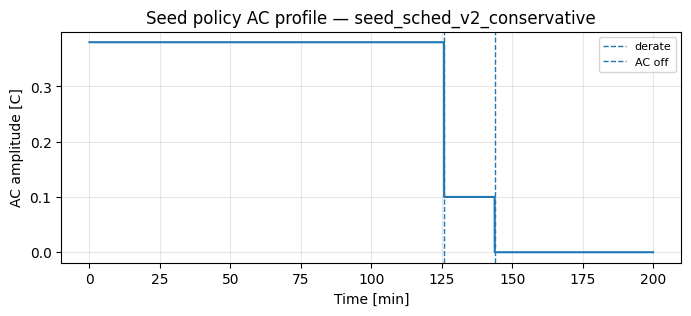

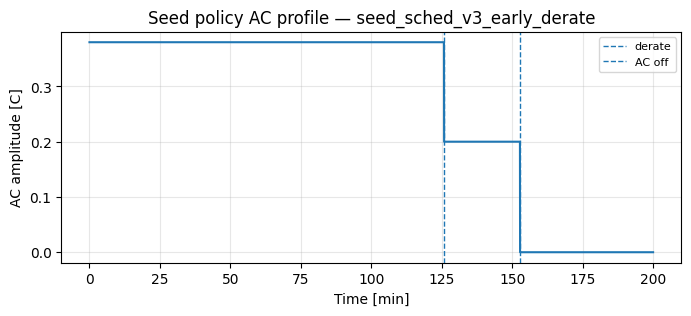

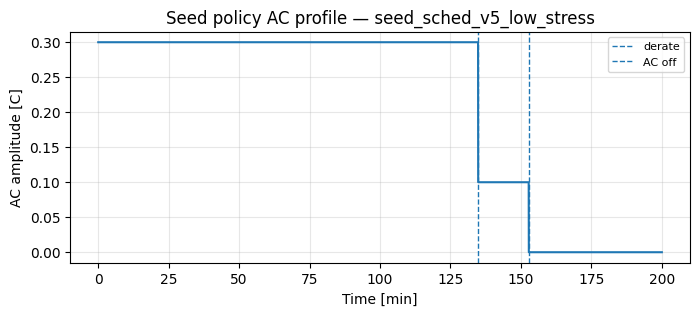

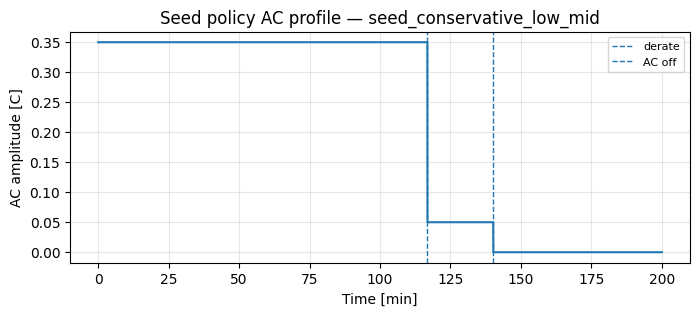

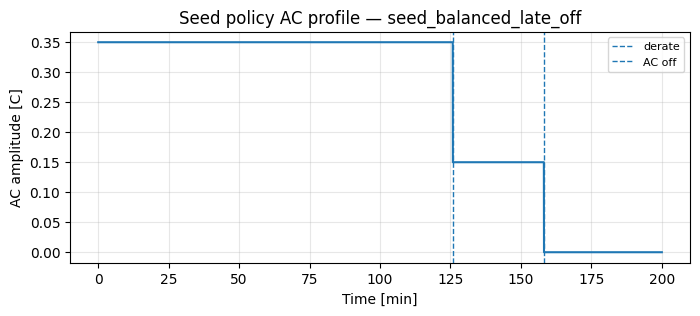

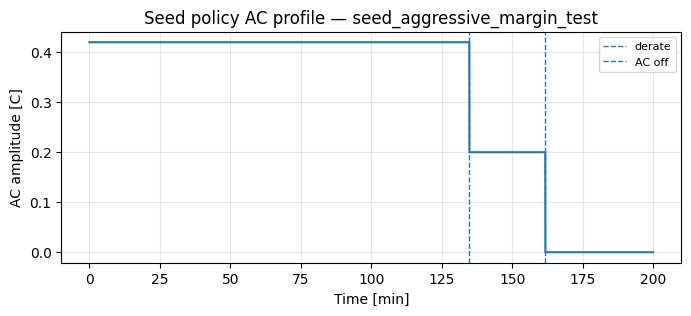

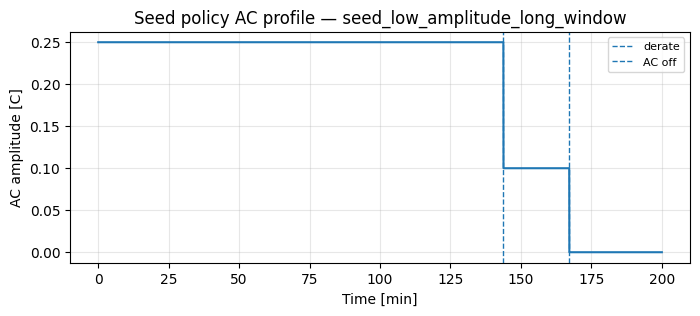

[OK] saved seed waveform audit: /Users/louislu/pybamm-dcac-superimposed/data/day38_seed_waveform_audit.csv
[OK] saved seed waveform summary: /Users/louislu/pybamm-dcac-superimposed/data/day38_seed_waveform_summary.csv


,policy_id,source,early_ac_c,mid_ac_c,qfrac_derate,qfrac_ac_off,I_charge_min_A,I_charge_max_A,AC_C_min,AC_C_max,Q_geom_end_Ah,t_derate_min,t_ac_off_min
0,seed_sched_v2_conservative,Day35_primary_candidate,0.38,0.10,0.70,0.80,-4.000000e-01,3.40,0.0,0.38,5.006584,125.800612,143.772128
1,seed_sched_v3_early_derate,Day35_balanced_candidate,0.38,0.20,0.70,0.85,-4.000000e-01,3.40,0.0,0.38,5.013241,125.800612,152.757886
2,seed_sched_v5_low_stress,Day35_low_stress_candidate,0.30,0.10,0.75,0.85,2.266811e-08,3.00,0.0,0.30,5.031818,134.786370,152.757886
3,seed_conservative_low_mid,Day38_seed,0.35,0.05,0.65,0.78,-2.500000e-01,3.25,0.0,0.35,5.052324,116.814854,140.177825
4,seed_balanced_late_off,Day38_seed,0.35,0.15,0.70,0.88,-2.500000e-01,3.25,0.0,0.35,5.014205,125.800612,158.149341
5,seed_aggressive_margin_test,Day38_seed,0.42,0.20,0.75,0.90,-6.000000e-01,3.60,0.0,0.42,5.052390,134.786370,161.743644
6,seed_low_amplitude_long_window,Day38_seed,0.25,0.10,0.80,0.93,2.500000e-01,2.75,0.0,0.25,5.017955,143.772128,167.135099


In [5]:
# Cell 5 — Current waveform utilities and seed-policy waveform audit（电流波形工具与种子策略波形审计）

def qfrac_to_time_s(q_frac):
    return q_frac * Q_REF_AH * 3600.0 / I_DC_A


def ac_amplitude_c_at_time_policy(t_s, policy_row):
    t_s = np.asarray(t_s, dtype=float)

    t_derate = qfrac_to_time_s(float(policy_row["qfrac_derate"]))
    t_off = qfrac_to_time_s(float(policy_row["qfrac_ac_off"]))

    ac = np.zeros_like(t_s, dtype=float)
    ac[t_s < t_derate] = float(policy_row["early_ac_c"])
    ac[(t_s >= t_derate) & (t_s < t_off)] = float(policy_row["mid_ac_c"])
    ac[t_s >= t_off] = 0.0

    return ac


def charge_current_A_policy(t_s, policy_row, q_nom_Ah=Q_NOM_AH):
    t_s = np.asarray(t_s, dtype=float)
    i_dc = DC_C * q_nom_Ah
    ac_c = ac_amplitude_c_at_time_policy(t_s, policy_row)
    i_ac = ac_c * q_nom_Ah

    return i_dc + i_ac * np.sin(2.0 * np.pi * F_MAIN_HZ * t_s)


def cumulative_trapezoid_np(y, x):
    y = np.asarray(y, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)

    if len(y) != len(x):
        raise ValueError("x and y length mismatch")

    if len(y) < 2:
        return np.zeros_like(y)

    dx = np.diff(x)
    area = 0.5 * (y[:-1] + y[1:]) * dx
    return np.concatenate([[0.0], np.cumsum(area)])


def sample_seed_policy_waveform(policy_row, t_max_s=12000.0, dt_s=1.0):
    t = np.arange(0.0, t_max_s + dt_s, dt_s)
    ac_c = ac_amplitude_c_at_time_policy(t, policy_row)
    i_charge = charge_current_A_policy(t, policy_row)
    q_geom = cumulative_trapezoid_np(i_charge, t) / 3600.0

    return pd.DataFrame({
        "t_s": t,
        "AC_C_scheduled": ac_c,
        "I_charge_A": i_charge,
        "I_py_A": -i_charge,
        "Q_geom_Ah": q_geom,
    })


waveform_rows = []
waveform_records = []

for _, row in seed_policy_df.iterrows():
    wf = sample_seed_policy_waveform(row.to_dict())
    wf["policy_id"] = row["policy_id"]
    waveform_records.append(wf)

    waveform_rows.append({
        "policy_id": row["policy_id"],
        "source": row["source"],
        "early_ac_c": row["early_ac_c"],
        "mid_ac_c": row["mid_ac_c"],
        "qfrac_derate": row["qfrac_derate"],
        "qfrac_ac_off": row["qfrac_ac_off"],
        "I_charge_min_A": float(wf["I_charge_A"].min()),
        "I_charge_max_A": float(wf["I_charge_A"].max()),
        "AC_C_min": float(wf["AC_C_scheduled"].min()),
        "AC_C_max": float(wf["AC_C_scheduled"].max()),
        "Q_geom_end_Ah": float(wf["Q_geom_Ah"].max()),
        "t_derate_min": qfrac_to_time_s(row["qfrac_derate"]) / 60.0,
        "t_ac_off_min": qfrac_to_time_s(row["qfrac_ac_off"]) / 60.0,
    })

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(wf["t_s"] / 60.0, wf["AC_C_scheduled"])
    ax.axvline(qfrac_to_time_s(row["qfrac_derate"]) / 60.0, linestyle="--", linewidth=1, label="derate")
    ax.axvline(qfrac_to_time_s(row["qfrac_ac_off"]) / 60.0, linestyle="--", linewidth=1, label="AC off")
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("AC amplitude [C]")
    ax.set_title(f"Seed policy AC profile — {row['policy_id']}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()

seed_waveform_df = pd.concat(waveform_records, ignore_index=True)
seed_waveform_summary_df = pd.DataFrame(waveform_rows)

out = DATA_DIR / "day38_seed_waveform_audit.csv"
seed_waveform_df.to_csv(out, index=False)

out2 = DATA_DIR / "day38_seed_waveform_summary.csv"
seed_waveform_summary_df.to_csv(out2, index=False)

print("[OK] saved seed waveform audit:", out)
print("[OK] saved seed waveform summary:", out2)
display(seed_waveform_summary_df)

## Day38B — Seed-policy evaluator and BO-ready scoring

Day38A froze the BO-ready policy parameterization:

```text
θ = {early_ac_c, mid_ac_c, qfrac_derate, qfrac_ac_off}
```

Day38B now builds the evaluator:

```text
policy θ
→ prescribed-current waveform
→ PyBaMM run
→ timing / geometry-residual / U_NE / microstate metrics
→ constraint verdict
→ scalar BO-ready screening score
```

This still does not perform Bayesian optimization. It evaluates the seed policies and defines the objective / constraint contract that BO can use later.

In [7]:
# Cell 6 — PyBaMM evaluator utilities for BO-ready policies（BO-ready策略的PyBaMM评价工具）

NE_SURFACE_KEY = "Negative electrode surface potential difference [V]"
NE_SEPARATOR_KEY = "Negative electrode surface potential difference at separator interface [V]"
NE_XAVG_KEY = "X-averaged negative electrode surface potential difference [V]"
ELYTE_C_KEY = "Electrolyte concentration [mol.m-3]"
ETA_N_KEY = "X-averaged negative electrode reaction overpotential [V]"
ETA_P_KEY = "X-averaged positive electrode reaction overpotential [V]"
NEG_AVG_STO_KEY = "Average negative particle stoichiometry"
NEG_SURF_STO_XAVG_KEY = "X-averaged negative particle surface stoichiometry"
NEG_SURF_STO_MAX_KEY = "Maximum negative particle surface stoichiometry"
NEG_SURF_STO_MIN_KEY = "Minimum negative particle surface stoichiometry"

def make_day38_model():
    return pybamm.lithium_ion.DFN({
        "thermal": "isothermal",
        "surface form": "false",
    })


def make_policy_row_from_theta(theta, policy_id="candidate_policy", source="manual_or_bo"):
    row = {
        "policy_id": policy_id,
        "source": source,
        "early_ac_c": float(theta["early_ac_c"]),
        "mid_ac_c": float(theta["mid_ac_c"]),
        "qfrac_derate": float(theta["qfrac_derate"]),
        "qfrac_ac_off": float(theta["qfrac_ac_off"]),
        "dc_c": DC_C,
        "tau_factor_set": TAU_FACTOR_MAIN,
        "f_Hz": F_MAIN_HZ,
        "period_s": PERIOD_MAIN_S,
        "peak_c_nominal": DC_C + float(theta["early_ac_c"]),
        "schedule_type": "qfrac_time_proxy",
    }

    feasible, reason = is_policy_feasible(row)
    row["feasible_parameter_space"] = feasible
    row["feasibility_reason"] = reason

    return row


def make_parameter_values_with_policy_current(policy_row, max_time_s=24000, current_dt_s=1.0):
    pv = pybamm.ParameterValues(PRIMARY_PARAMETER_SET)
    q_nom_Ah = float(pv["Nominal cell capacity [A.h]"])

    t_grid = np.arange(0.0, max_time_s + current_dt_s, current_dt_s)
    i_charge_grid = charge_current_A_policy(t_grid, policy_row, q_nom_Ah=q_nom_Ah)
    i_py_grid = -i_charge_grid

    current_interpolant = pybamm.Interpolant(
        t_grid,
        i_py_grid,
        pybamm.t,
        interpolator="linear",
    )

    pv.update({"Current function [A]": current_interpolant}, check_already_exists=False)

    q_geom_grid = cumulative_trapezoid_np(i_charge_grid, t_grid) / 3600.0
    ac_c_grid = ac_amplitude_c_at_time_policy(t_grid, policy_row)

    geom_df = pd.DataFrame({
        "t_s": t_grid,
        "I_charge_A": i_charge_grid,
        "I_py_A": i_py_grid,
        "Q_geom_Ah": q_geom_grid,
        "AC_C_scheduled": ac_c_grid,
    })

    return pv, geom_df


def extract_basic_timeseries(sol):
    t_s = np.asarray(sol.t, dtype=float)
    I_py_A = np.asarray(sol["Current [A]"](t_s), dtype=float).reshape(-1)
    V_terminal_V = np.asarray(sol["Terminal voltage [V]"](t_s), dtype=float).reshape(-1)

    I_charge_A = -I_py_A
    Q_net_Ah = cumulative_trapezoid_np(I_charge_A, t_s) / 3600.0

    return pd.DataFrame({
        "t_s": t_s,
        "I_py_A": I_py_A,
        "I_charge_A": I_charge_A,
        "V_terminal_V": V_terminal_V,
        "Q_net_Ah": Q_net_Ah,
    })


def run_day38_policy(policy_row, initial_soc=0.05, max_time_s=24000, n_eval=5000, current_dt_s=1.0):
    if policy_row.get("feasible_parameter_space", True) is False:
        raise ValueError(f"Policy not feasible in parameter space: {policy_row.get('feasibility_reason')}")

    model = make_day38_model()
    pv, geom_df = make_parameter_values_with_policy_current(
        policy_row=policy_row,
        max_time_s=max_time_s,
        current_dt_s=current_dt_s,
    )

    sim = pybamm.Simulation(model, parameter_values=pv)
    t_eval = np.linspace(0.0, max_time_s, n_eval)
    sol = sim.solve(t_eval=t_eval, initial_soc=initial_soc)
    ts = extract_basic_timeseries(sol)

    return {
        "sim": sim,
        "sol": sol,
        "ts": ts,
        "geom": geom_df,
        "policy": dict(policy_row),
    }


def reduce_to_timeseries(arr, t_s, reducer="mean"):
    arr = np.asarray(arr, dtype=float)
    t_s = np.asarray(t_s, dtype=float)
    n_t = len(t_s)

    if arr.ndim == 0:
        return np.full(n_t, float(arr))

    if arr.ndim == 1:
        if arr.shape[0] == n_t:
            return arr
        return np.full(n_t, np.nanmean(arr))

    if arr.shape[-1] == n_t:
        flat = arr.reshape(-1, n_t)
        axis = 0
    elif arr.shape[0] == n_t:
        flat = arr.reshape(n_t, -1)
        axis = 1
    else:
        raise ValueError(f"Cannot identify time axis: arr.shape={arr.shape}, n_t={n_t}")

    if reducer == "min":
        return np.nanmin(flat, axis=axis)
    if reducer == "max":
        return np.nanmax(flat, axis=axis)
    if reducer == "mean":
        return np.nanmean(flat, axis=axis)

    raise ValueError(reducer)


def safe_extract(sol, key, t_s, reducer="mean"):
    try:
        return reduce_to_timeseries(sol[key](t_s), t_s, reducer=reducer)
    except Exception:
        return np.full(len(t_s), np.nan)


def classify_margin_mV(u_mV):
    if pd.isna(u_mV):
        return "unresolved"
    if u_mV <= PLATING_MARGIN_HARD_LIMIT_MV:
        return "risk_flag"
    if u_mV <= PLATING_MARGIN_BUFFER_MV:
        return "near_boundary"
    return "safe_margin"

print("[OK] Day38 evaluator utilities ready")

[OK] Day38 evaluator utilities ready


In [8]:
# Cell 7 — Run DC reference and seed policies（运行DC基准与种子策略）

# Add a DC reference row for timing decomposition.
dc_reference_policy = {
    "policy_id": "DC03_reference",
    "source": "reference",
    "early_ac_c": 0.0,
    "mid_ac_c": 0.0,
    "qfrac_derate": 0.70,
    "qfrac_ac_off": 0.80,
    "dc_c": DC_C,
    "tau_factor_set": TAU_FACTOR_MAIN,
    "f_Hz": F_MAIN_HZ,
    "period_s": PERIOD_MAIN_S,
    "peak_c_nominal": DC_C,
    "schedule_type": "qfrac_time_proxy",
    "feasible_parameter_space": True,
    "feasibility_reason": "reference",
}

# For DC reference, override current functions by using zero AC amplitudes.
seed_eval_rows = [dc_reference_policy] + seed_policy_df.to_dict("records")

solutions = {}
run_rows = []

for row in seed_eval_rows:
    policy_id = row["policy_id"]
    print(f"\n[RUN] {policy_id}")

    try:
        result = run_day38_policy(row)
        solutions[policy_id] = result
        ts = result["ts"]
        geom = result["geom"]

        run_rows.append({
            "policy_id": policy_id,
            "source": row.get("source", ""),
            "status": "ok",
            "termination": str(result["sol"].termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60.0),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "AC_C_min": float(geom["AC_C_scheduled"].min()),
            "AC_C_max": float(geom["AC_C_scheduled"].max()),
            "early_ac_c": row["early_ac_c"],
            "mid_ac_c": row["mid_ac_c"],
            "qfrac_derate": row["qfrac_derate"],
            "qfrac_ac_off": row["qfrac_ac_off"],
            "error": "",
        })

        print("[OK]", policy_id, "| termination:", result["sol"].termination)

    except Exception as e:
        run_rows.append({
            "policy_id": policy_id,
            "source": row.get("source", ""),
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "AC_C_min": np.nan,
            "AC_C_max": np.nan,
            "early_ac_c": row["early_ac_c"],
            "mid_ac_c": row["mid_ac_c"],
            "qfrac_derate": row["qfrac_derate"],
            "qfrac_ac_off": row["qfrac_ac_off"],
            "error": repr(e),
        })
        print("[FAILED]", policy_id, repr(e))

day38_seed_run_summary_df = pd.DataFrame(run_rows)

out = DATA_DIR / "day38_seed_run_summary.csv"
day38_seed_run_summary_df.to_csv(out, index=False)

print("[OK] saved seed run summary:", out)
display(day38_seed_run_summary_df)


[RUN] DC03_reference
[OK] DC03_reference | termination: event: Maximum voltage [V]

[RUN] seed_sched_v2_conservative
[OK] seed_sched_v2_conservative | termination: event: Maximum voltage [V]

[RUN] seed_sched_v3_early_derate
[OK] seed_sched_v3_early_derate | termination: event: Maximum voltage [V]

[RUN] seed_sched_v5_low_stress
[OK] seed_sched_v5_low_stress | termination: event: Maximum voltage [V]

[RUN] seed_conservative_low_mid
[OK] seed_conservative_low_mid | termination: event: Maximum voltage [V]

[RUN] seed_balanced_late_off
[OK] seed_balanced_late_off | termination: event: Maximum voltage [V]

[RUN] seed_aggressive_margin_test
[OK] seed_aggressive_margin_test | termination: event: Maximum voltage [V]

[RUN] seed_low_amplitude_long_window
[OK] seed_low_amplitude_long_window | termination: event: Maximum voltage [V]
[OK] saved seed run summary: /Users/louislu/pybamm-dcac-superimposed/data/day38_seed_run_summary.csv


,policy_id,source,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,AC_C_min,AC_C_max,early_ac_c,mid_ac_c,qfrac_derate,qfrac_ac_off,error
0,DC03_reference,reference,ok,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000,1.500000,0.0,0.00,0.00,0.00,0.70,0.80,
1,seed_sched_v2_conservative,Day35_primary_candidate,ok,event: Maximum voltage [V],10767.715806,179.461930,4.493120,4.2,-0.399987,3.399991,0.0,0.38,0.38,0.10,0.70,0.80,
2,seed_sched_v3_early_derate,Day35_balanced_candidate,ok,event: Maximum voltage [V],10751.242289,179.187371,4.492913,4.2,-0.399987,3.399991,0.0,0.38,0.38,0.20,0.70,0.85,
3,seed_sched_v5_low_stress,Day35_low_stress_candidate,ok,event: Maximum voltage [V],10704.744895,178.412415,4.492125,4.2,0.000006,2.999980,0.0,0.30,0.30,0.10,0.75,0.85,
4,seed_conservative_low_mid,Day38_seed,ok,event: Maximum voltage [V],10655.560530,177.592675,4.492131,4.2,-0.250000,3.249983,0.0,0.35,0.35,0.05,0.65,0.78,
5,seed_balanced_late_off,Day38_seed,ok,event: Maximum voltage [V],10747.083538,179.118059,4.492147,4.2,-0.250000,3.249983,0.0,0.35,0.35,0.15,0.70,0.88,
6,seed_aggressive_margin_test,Day38_seed,ok,event: Maximum voltage [V],10653.799871,177.563331,4.491456,4.2,-0.599993,3.599983,0.0,0.42,0.42,0.20,0.75,0.90,
7,seed_low_amplitude_long_window,Day38_seed,ok,event: Maximum voltage [V],10738.370183,178.972836,4.492272,4.2,0.250005,2.749990,0.0,0.25,0.25,0.10,0.80,0.93,


In [9]:
# Cell 8 — Extract seed-policy margin and microstate features（提取种子策略余量与微观状态特征）

state_ts_map = {}
state_rows = []

for policy_id, obj in solutions.items():
    print("[EXTRACT]", policy_id)

    sol = obj["sol"]
    ts = obj["ts"].copy()
    t_s = ts["t_s"].to_numpy()

    ne_surface = sol[NE_SURFACE_KEY](t_s)
    ts["U_NE_min_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="min")
    ts["U_NE_min_mV"] = ts["U_NE_min_V"] * 1000.0
    ts["U_NE_xavg_V"] = safe_extract(sol, NE_XAVG_KEY, t_s, reducer="mean")

    c_e = sol[ELYTE_C_KEY](t_s)
    ts["c_e_min_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="min")
    ts["c_e_max_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="max")
    ts["c_e_range_molm3"] = ts["c_e_max_molm3"] - ts["c_e_min_molm3"]

    ts["eta_n_V"] = safe_extract(sol, ETA_N_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_xavg"] = safe_extract(sol, NEG_SURF_STO_XAVG_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_max"] = safe_extract(sol, NEG_SURF_STO_MAX_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_min"] = safe_extract(sol, NEG_SURF_STO_MIN_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_range"] = ts["neg_surface_sto_max"] - ts["neg_surface_sto_min"]

    state_ts_map[policy_id] = ts

    idx_min = int(ts["U_NE_min_V"].idxmin())
    r = ts.loc[idx_min]

    state_rows.append({
        "policy_id": policy_id,
        "min_U_NE_mV": float(r["U_NE_min_mV"]),
        "margin_class": classify_margin_mV(float(r["U_NE_min_mV"])),
        "fraction_time_below_0mV": float((ts["U_NE_min_mV"] <= PLATING_MARGIN_HARD_LIMIT_MV).mean()),
        "fraction_time_below_50mV": float((ts["U_NE_min_mV"] <= PLATING_MARGIN_BUFFER_MV).mean()),
        "Q_at_min_U_NE_Ah": float(r["Q_net_Ah"]),
        "t_at_min_U_NE_s": float(r["t_s"]),
        "I_charge_at_min_U_NE_A": float(r["I_charge_A"]),
        "I_charge_peak_observed_A": float(ts["I_charge_A"].max()),
        "V_terminal_at_min_U_NE_V": float(r["V_terminal_V"]),
        "max_c_e_range_molm3": float(ts["c_e_range_molm3"].max()),
        "c_e_range_at_min_U_NE_molm3": float(r["c_e_range_molm3"]),
        "max_neg_surface_sto_range": float(np.nanmax(ts["neg_surface_sto_range"])),
        "surface_range_at_min_U_NE": float(r["neg_surface_sto_range"]),
        "eta_n_at_min_U_NE_V": float(r["eta_n_V"]),
    })

day38_seed_state_summary_df = pd.DataFrame(state_rows)

# Normalize microstate metrics to DC reference.
dc_state = day38_seed_state_summary_df[day38_seed_state_summary_df["policy_id"] == "DC03_reference"].iloc[0]

day38_seed_state_summary_df["max_c_e_range_vs_DC"] = (
    day38_seed_state_summary_df["max_c_e_range_molm3"] / dc_state["max_c_e_range_molm3"]
)
day38_seed_state_summary_df["surface_range_at_min_vs_DC"] = (
    day38_seed_state_summary_df["surface_range_at_min_U_NE"] / dc_state["surface_range_at_min_U_NE"]
)
day38_seed_state_summary_df["abs_eta_n_at_min_vs_DC"] = (
    day38_seed_state_summary_df["eta_n_at_min_U_NE_V"].abs() / abs(dc_state["eta_n_at_min_U_NE_V"])
)

out = DATA_DIR / "day38_seed_state_margin_microstate_summary.csv"
day38_seed_state_summary_df.to_csv(out, index=False)

print("[OK] saved seed state/margin/microstate summary:", out)
display(day38_seed_state_summary_df)

[EXTRACT] DC03_reference
[EXTRACT] seed_sched_v2_conservative
[EXTRACT] seed_sched_v3_early_derate
[EXTRACT] seed_sched_v5_low_stress
[EXTRACT] seed_conservative_low_mid
[EXTRACT] seed_balanced_late_off
[EXTRACT] seed_aggressive_margin_test
[EXTRACT] seed_low_amplitude_long_window
[OK] saved seed state/margin/microstate summary: /Users/louislu/pybamm-dcac-superimposed/data/day38_seed_state_margin_microstate_summary.csv


,policy_id,min_U_NE_mV,margin_class,fraction_time_below_0mV,fraction_time_below_50mV,Q_at_min_U_NE_Ah,t_at_min_U_NE_s,I_charge_at_min_U_NE_A,I_charge_peak_observed_A,V_terminal_at_min_U_NE_V,max_c_e_range_molm3,c_e_range_at_min_U_NE_molm3,max_neg_surface_sto_range,surface_range_at_min_U_NE,eta_n_at_min_U_NE_V,max_c_e_range_vs_DC,surface_range_at_min_vs_DC,abs_eta_n_at_min_vs_DC
0,DC03_reference,37.280562,near_boundary,0.0,0.219837,4.492879,10782.909607,1.500000,1.500000,4.200000,377.868423,354.118549,0.116717,0.116717,-0.045310,1.000000,1.000000,1.000000
1,seed_sched_v2_conservative,24.160262,near_boundary,0.0,0.225169,3.069916,7284.636651,3.359285,3.399991,4.043495,747.684843,733.219024,0.133279,0.094088,-0.068915,1.978691,0.806120,1.520948
2,seed_sched_v3_early_derate,20.499177,near_boundary,0.0,0.220506,3.764382,8991.725735,2.491721,3.399991,4.154232,747.684843,519.613457,0.133279,0.103983,-0.057342,1.978691,0.890900,1.265529
3,seed_sched_v5_low_stress,16.256867,near_boundary,0.0,0.200641,3.345738,7966.624060,2.980745,2.999980,4.090871,670.178359,623.705903,0.124459,0.078494,-0.063262,1.773576,0.672516,1.396201
4,seed_conservative_low_mid,35.078052,near_boundary,0.0,0.203415,2.924415,6942.188438,3.213657,3.249983,4.009670,712.634679,697.460955,0.129674,0.106265,-0.066164,1.885933,0.910451,1.460247
5,seed_balanced_late_off,25.041524,near_boundary,0.0,0.195634,3.902237,9333.066613,2.245347,3.249983,4.164816,718.609557,474.291574,0.129674,0.108406,-0.053954,1.901745,0.928798,1.190762
6,seed_aggressive_margin_test,3.647085,near_boundary,0.0,0.230821,3.355846,7966.213428,3.575532,3.599983,4.113792,786.254648,728.455980,0.138163,0.088518,-0.072492,2.080763,0.758401,1.599896
7,seed_low_amplitude_long_window,18.189742,near_boundary,0.0,0.182835,3.482260,8306.652876,2.741125,2.749990,4.109817,621.475704,565.602607,0.124102,0.082693,-0.059712,1.644688,0.708492,1.317849


In [10]:
# Cell 9 — Equal-Q timing and geometry-residual for seed policies（种子策略等Q时间与几何-残差）

def first_passage_time(t_s, q_Ah, q_target_Ah):
    t_s = np.asarray(t_s, dtype=float)
    q_Ah = np.asarray(q_Ah, dtype=float)

    hit = np.where(q_Ah >= q_target_Ah)[0]
    if len(hit) == 0:
        return np.nan

    i = int(hit[0])
    if i == 0:
        return float(t_s[0])

    q0, q1 = q_Ah[i - 1], q_Ah[i]
    t0, t1 = t_s[i - 1], t_s[i]

    if q1 == q0:
        return float(t1)

    frac = (q_target_Ah - q0) / (q1 - q0)
    return float(t0 + frac * (t1 - t0))


def first_passage_from_geom_df(geom_df, q_target_Ah):
    return first_passage_time(
        geom_df["t_s"].to_numpy(),
        geom_df["Q_geom_Ah"].to_numpy(),
        q_target_Ah,
    )


dc_ts = state_ts_map["DC03_reference"]
dc_geom = solutions["DC03_reference"]["geom"]

q_end_all = min(float(ts["Q_net_Ah"].max()) for pid, ts in state_ts_map.items())
q_grid = np.linspace(0.2, 0.95 * q_end_all, 100)

eq_rows = []

for policy_id, ts in state_ts_map.items():
    if policy_id == "DC03_reference":
        continue

    geom = solutions[policy_id]["geom"]

    for q in q_grid:
        t_dc = first_passage_time(dc_ts["t_s"], dc_ts["Q_net_Ah"], q)
        t_policy = first_passage_time(ts["t_s"], ts["Q_net_Ah"], q)
        t_dc_geom = first_passage_from_geom_df(dc_geom, q)
        t_policy_geom = first_passage_from_geom_df(geom, q)

        eq_rows.append({
            "policy_id": policy_id,
            "Q_Ah": float(q),
            "delta_t_raw_s": t_dc - t_policy,
            "delta_t_geom_s": t_dc_geom - t_policy_geom,
            "delta_t_resid_s": (t_dc - t_policy) - (t_dc_geom - t_policy_geom),
        })

day38_seed_equalq_df = pd.DataFrame(eq_rows)

out = DATA_DIR / "day38_seed_equalQ_timing_geom_resid_curves.csv"
day38_seed_equalq_df.to_csv(out, index=False)

day38_seed_timing_summary_df = (
    day38_seed_equalq_df
    .groupby("policy_id", as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
        delta_t_geom_mean_s=("delta_t_geom_s", "mean"),
        delta_t_resid_mean_s=("delta_t_resid_s", "mean"),
        resid_abs_mean_s=("delta_t_resid_s", lambda x: np.nanmean(np.abs(x))),
        resid_max_abs_s=("delta_t_resid_s", lambda x: np.nanmax(np.abs(x))),
        resid_positive_fraction=("delta_t_resid_s", lambda x: np.nanmean(np.asarray(x) > 0.0)),
    )
)

def classify_resid(row):
    raw = abs(row["delta_t_raw_mean_s"])
    if raw < 1:
        return "near_zero_or_unresolved"

    ratio = row["resid_abs_mean_s"] / raw

    if (row["delta_t_resid_mean_s"] > 5.0) and (row["resid_positive_fraction"] >= 0.75):
        return "candidate_positive_residual"

    if ratio < 0.05:
        return "geometry_dominated"
    if ratio < 0.20:
        return "mostly_geometry_small_residual"
    return "residual_non_negligible"

day38_seed_timing_summary_df["dt_resid_class"] = day38_seed_timing_summary_df.apply(classify_resid, axis=1)

out = DATA_DIR / "day38_seed_equalQ_timing_geom_resid_summary.csv"
day38_seed_timing_summary_df.to_csv(out, index=False)

print("[OK] saved seed equal-Q curves:", DATA_DIR / "day38_seed_equalQ_timing_geom_resid_curves.csv")
print("[OK] saved seed timing summary:", out)
display(day38_seed_timing_summary_df)

[OK] saved seed equal-Q curves: /Users/louislu/pybamm-dcac-superimposed/data/day38_seed_equalQ_timing_geom_resid_curves.csv
[OK] saved seed timing summary: /Users/louislu/pybamm-dcac-superimposed/data/day38_seed_equalQ_timing_geom_resid_summary.csv


,policy_id,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s,delta_t_geom_mean_s,delta_t_resid_mean_s,resid_abs_mean_s,resid_max_abs_s,resid_positive_fraction,dt_resid_class
0,seed_aggressive_margin_test,87.108479,0.018001,152.457485,87.128845,-0.020366,0.020366,0.117001,0.00,geometry_dominated
1,seed_balanced_late_off,55.449233,0.036708,127.062168,55.463087,-0.013854,0.013869,0.097116,0.01,geometry_dominated
2,seed_conservative_low_mid,83.315438,0.036708,127.062168,83.331054,-0.015616,0.015630,0.097116,0.01,geometry_dominated
3,seed_low_amplitude_long_window,44.442099,0.025177,90.732646,44.449001,-0.006903,0.006960,0.040208,0.01,geometry_dominated
4,seed_sched_v2_conservative,55.576168,0.041897,137.942458,55.593112,-0.016943,0.016963,0.071266,0.01,geometry_dominated
5,seed_sched_v3_early_derate,60.765309,0.041897,137.942458,60.782699,-0.017390,0.017409,0.089000,0.01,geometry_dominated
6,seed_sched_v5_low_stress,60.098551,0.025757,108.914108,60.110238,-0.011687,0.011705,0.226386,0.01,geometry_dominated


In [11]:
# Cell 10 — BO-ready score and constraint ledger for seed policies（种子策略BO-ready评分与约束账本）

seed_ledger_df = (
    seed_policy_df
    .merge(day38_seed_timing_summary_df, on="policy_id", how="left")
    .merge(day38_seed_state_summary_df, on="policy_id", how="left")
)

# Constraint flags.
seed_ledger_df["hard_margin_violation"] = seed_ledger_df["min_U_NE_mV"] <= PLATING_MARGIN_HARD_LIMIT_MV
seed_ledger_df["buffer_margin_exposure"] = seed_ledger_df["fraction_time_below_50mV"] > 0
seed_ledger_df["peak_current_soft_violation"] = seed_ledger_df["peak_c_nominal"] > POLICY_CONSTRAINTS["peak_current_soft_limit_c"]

# BO-ready score. Deliberately simple and transparent.
# Maximize raw timing gain, reward U_NE margin, penalize hard violations and transport stress.
gain_reference_s = 80.0
gain_norm = np.clip(seed_ledger_df["delta_t_raw_mean_s"] / gain_reference_s, 0.0, 2.0)
margin_norm = np.clip(seed_ledger_df["min_U_NE_mV"] / PLATING_MARGIN_BUFFER_MV, -1.0, 1.0)
transport_penalty = np.clip((seed_ledger_df["max_c_e_range_vs_DC"] - 1.0) / 2.0, 0.0, 2.0)
surface_penalty = np.clip((seed_ledger_df["surface_range_at_min_vs_DC"] - 1.0), 0.0, 2.0)
eta_penalty = np.clip((seed_ledger_df["abs_eta_n_at_min_vs_DC"] - 1.0) / 2.0, 0.0, 2.0)

hard_margin_penalty = seed_ledger_df["hard_margin_violation"].astype(float) * 2.0
peak_soft_penalty = seed_ledger_df["peak_current_soft_violation"].astype(float) * 0.25

seed_ledger_df["bo_ready_score"] = (
    0.45 * gain_norm
    + 0.35 * margin_norm
    - 0.10 * transport_penalty
    - 0.05 * surface_penalty
    - 0.05 * eta_penalty
    - hard_margin_penalty
    - peak_soft_penalty
)

def classify_constraint_verdict(row):
    if row["hard_margin_violation"]:
        return "infeasible_hard_margin"
    if row["peak_current_soft_violation"]:
        return "feasible_but_peak_current_soft_violation"
    if row["min_U_NE_mV"] <= PLATING_MARGIN_BUFFER_MV:
        return "feasible_near_boundary"
    return "feasible_safe_margin"

seed_ledger_df["constraint_verdict"] = seed_ledger_df.apply(classify_constraint_verdict, axis=1)

out = DATA_DIR / "day38_seed_bo_ready_evaluation_ledger.csv"
seed_ledger_df.to_csv(out, index=False)

print("[OK] saved BO-ready seed evaluation ledger:", out)

display_cols = [
    "policy_id",
    "early_ac_c",
    "mid_ac_c",
    "qfrac_derate",
    "qfrac_ac_off",
    "peak_c_nominal",
    "delta_t_raw_mean_s",
    "delta_t_geom_mean_s",
    "delta_t_resid_mean_s",
    "dt_resid_class",
    "min_U_NE_mV",
    "fraction_time_below_0mV",
    "fraction_time_below_50mV",
    "max_c_e_range_vs_DC",
    "surface_range_at_min_vs_DC",
    "abs_eta_n_at_min_vs_DC",
    "hard_margin_violation",
    "peak_current_soft_violation",
    "constraint_verdict",
    "bo_ready_score",
]

display(seed_ledger_df[display_cols].sort_values("bo_ready_score", ascending=False))

[OK] saved BO-ready seed evaluation ledger: /Users/louislu/pybamm-dcac-superimposed/data/day38_seed_bo_ready_evaluation_ledger.csv


,policy_id,early_ac_c,mid_ac_c,qfrac_derate,qfrac_ac_off,peak_c_nominal,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,dt_resid_class,min_U_NE_mV,fraction_time_below_0mV,fraction_time_below_50mV,max_c_e_range_vs_DC,surface_range_at_min_vs_DC,abs_eta_n_at_min_vs_DC,hard_margin_violation,peak_current_soft_violation,constraint_verdict,bo_ready_score
3,seed_conservative_low_mid,0.35,0.05,0.65,0.78,0.65,83.315438,83.331054,-0.015616,geometry_dominated,35.078052,0.0,0.203415,1.885933,0.910451,1.460247,False,False,feasible_near_boundary,0.658393
5,seed_aggressive_margin_test,0.42,0.20,0.75,0.90,0.72,87.108479,87.128845,-0.020366,geometry_dominated,3.647085,0.0,0.230821,2.080763,0.758401,1.599896,False,False,feasible_near_boundary,0.446479
4,seed_balanced_late_off,0.35,0.15,0.70,0.88,0.65,55.449233,55.463087,-0.013854,geometry_dominated,25.041524,0.0,0.195634,1.901745,0.928798,1.190762,False,False,feasible_near_boundary,0.437336
1,seed_sched_v3_early_derate,0.38,0.20,0.70,0.85,0.68,60.765309,60.782699,-0.017390,geometry_dominated,20.499177,0.0,0.220506,1.978691,0.890900,1.265529,False,False,feasible_near_boundary,0.429726
0,seed_sched_v2_conservative,0.38,0.10,0.70,0.80,0.68,55.576168,55.593112,-0.016943,geometry_dominated,24.160262,0.0,0.225169,1.978691,0.806120,1.520948,False,False,feasible_near_boundary,0.419780
2,seed_sched_v5_low_stress,0.30,0.10,0.75,0.85,0.60,60.098551,60.110238,-0.011687,geometry_dominated,16.256867,0.0,0.200641,1.773576,0.672516,1.396201,False,False,feasible_near_boundary,0.403269
6,seed_low_amplitude_long_window,0.25,0.10,0.80,0.93,0.55,44.442099,44.449001,-0.006903,geometry_dominated,18.189742,0.0,0.182835,1.644688,0.708492,1.317849,False,False,feasible_near_boundary,0.337134


In [12]:
# Cell 11 — Define single-policy evaluator contract（定义单策略评价器接口）

def evaluate_policy_theta(theta, policy_id="bo_candidate"):
    """
    BO-ready evaluator contract.

    Input:
        theta = {
            "early_ac_c": float,
            "mid_ac_c": float,
            "qfrac_derate": float,
            "qfrac_ac_off": float,
        }

    Output:
        dict with timing, margin, microstate, constraint, and score metrics.

    Notes:
        This function runs a full PyBaMM DFN evaluation.
        It is intentionally expensive and should be wrapped by BO only after seed validation.
    """
    policy_row = make_policy_row_from_theta(theta, policy_id=policy_id, source="bo_candidate")

    feasible, reason = is_policy_feasible(policy_row)
    if not feasible:
        return {
            "policy_id": policy_id,
            "feasible_parameter_space": False,
            "feasibility_reason": reason,
            "bo_ready_score": -999.0,
            "constraint_verdict": "invalid_parameter_space",
        }

    obj = run_day38_policy(policy_row)
    ts = obj["ts"]
    geom = obj["geom"]

    # State extraction.
    sol = obj["sol"]
    t_s = ts["t_s"].to_numpy()

    ne_surface = sol[NE_SURFACE_KEY](t_s)
    ts["U_NE_min_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="min")
    ts["U_NE_min_mV"] = ts["U_NE_min_V"] * 1000.0

    c_e = sol[ELYTE_C_KEY](t_s)
    ts["c_e_min_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="min")
    ts["c_e_max_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="max")
    ts["c_e_range_molm3"] = ts["c_e_max_molm3"] - ts["c_e_min_molm3"]

    ts["eta_n_V"] = safe_extract(sol, ETA_N_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_max"] = safe_extract(sol, NEG_SURF_STO_MAX_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_min"] = safe_extract(sol, NEG_SURF_STO_MIN_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_range"] = ts["neg_surface_sto_max"] - ts["neg_surface_sto_min"]

    idx_min = int(ts["U_NE_min_V"].idxmin())
    r = ts.loc[idx_min]

    # Timing vs already computed DC reference.
    q_hi = min(float(ts["Q_net_Ah"].max()), float(dc_ts["Q_net_Ah"].max()))
    q_grid_local = np.linspace(0.2, 0.95 * q_hi, 100)

    eq_local = []
    for q in q_grid_local:
        t_dc = first_passage_time(dc_ts["t_s"], dc_ts["Q_net_Ah"], q)
        t_policy = first_passage_time(ts["t_s"], ts["Q_net_Ah"], q)
        t_dc_geom = first_passage_from_geom_df(dc_geom, q)
        t_policy_geom = first_passage_from_geom_df(geom, q)
        eq_local.append({
            "delta_t_raw_s": t_dc - t_policy,
            "delta_t_geom_s": t_dc_geom - t_policy_geom,
            "delta_t_resid_s": (t_dc - t_policy) - (t_dc_geom - t_policy_geom),
        })

    eq_df = pd.DataFrame(eq_local)

    delta_t_raw_mean_s = float(eq_df["delta_t_raw_s"].mean())
    delta_t_geom_mean_s = float(eq_df["delta_t_geom_s"].mean())
    delta_t_resid_mean_s = float(eq_df["delta_t_resid_s"].mean())
    resid_abs_mean_s = float(np.nanmean(np.abs(eq_df["delta_t_resid_s"])))
    resid_positive_fraction = float(np.nanmean(eq_df["delta_t_resid_s"] > 0.0))

    tmp_row = pd.Series({
        "delta_t_raw_mean_s": delta_t_raw_mean_s,
        "delta_t_resid_mean_s": delta_t_resid_mean_s,
        "resid_abs_mean_s": resid_abs_mean_s,
        "resid_positive_fraction": resid_positive_fraction,
    })
    dt_resid_class = classify_resid(tmp_row)

    # Normalize to DC reference from current seed extraction.
    dc_state = day38_seed_state_summary_df[day38_seed_state_summary_df["policy_id"] == "DC03_reference"].iloc[0]

    max_c_e_range_vs_DC = float(ts["c_e_range_molm3"].max()) / dc_state["max_c_e_range_molm3"]
    surface_range_at_min_vs_DC = float(r["neg_surface_sto_range"]) / dc_state["surface_range_at_min_U_NE"]
    abs_eta_n_at_min_vs_DC = abs(float(r["eta_n_V"])) / abs(dc_state["eta_n_at_min_U_NE_V"])

    min_U_NE_mV = float(r["U_NE_min_mV"])
    fraction_time_below_0mV = float((ts["U_NE_min_mV"] <= PLATING_MARGIN_HARD_LIMIT_MV).mean())
    fraction_time_below_50mV = float((ts["U_NE_min_mV"] <= PLATING_MARGIN_BUFFER_MV).mean())

    hard_margin_violation = min_U_NE_mV <= PLATING_MARGIN_HARD_LIMIT_MV
    peak_current_soft_violation = (DC_C + policy_row["early_ac_c"]) > POLICY_CONSTRAINTS["peak_current_soft_limit_c"]

    # Same score formula as seed ledger.
    gain_norm = np.clip(delta_t_raw_mean_s / gain_reference_s, 0.0, 2.0)
    margin_norm = np.clip(min_U_NE_mV / PLATING_MARGIN_BUFFER_MV, -1.0, 1.0)
    transport_penalty = np.clip((max_c_e_range_vs_DC - 1.0) / 2.0, 0.0, 2.0)
    surface_penalty = np.clip((surface_range_at_min_vs_DC - 1.0), 0.0, 2.0)
    eta_penalty = np.clip((abs_eta_n_at_min_vs_DC - 1.0) / 2.0, 0.0, 2.0)
    hard_margin_penalty = float(hard_margin_violation) * 2.0
    peak_soft_penalty = float(peak_current_soft_violation) * 0.25

    score = (
        0.45 * gain_norm
        + 0.35 * margin_norm
        - 0.10 * transport_penalty
        - 0.05 * surface_penalty
        - 0.05 * eta_penalty
        - hard_margin_penalty
        - peak_soft_penalty
    )

    if hard_margin_violation:
        constraint_verdict = "infeasible_hard_margin"
    elif peak_current_soft_violation:
        constraint_verdict = "feasible_but_peak_current_soft_violation"
    elif min_U_NE_mV <= PLATING_MARGIN_BUFFER_MV:
        constraint_verdict = "feasible_near_boundary"
    else:
        constraint_verdict = "feasible_safe_margin"

    return {
        "policy_id": policy_id,
        "feasible_parameter_space": True,
        "feasibility_reason": "ok",
        **{k: policy_row[k] for k in ["early_ac_c", "mid_ac_c", "qfrac_derate", "qfrac_ac_off"]},
        "delta_t_raw_mean_s": delta_t_raw_mean_s,
        "delta_t_geom_mean_s": delta_t_geom_mean_s,
        "delta_t_resid_mean_s": delta_t_resid_mean_s,
        "resid_abs_mean_s": resid_abs_mean_s,
        "resid_positive_fraction": resid_positive_fraction,
        "dt_resid_class": dt_resid_class,
        "min_U_NE_mV": min_U_NE_mV,
        "fraction_time_below_0mV": fraction_time_below_0mV,
        "fraction_time_below_50mV": fraction_time_below_50mV,
        "max_c_e_range_vs_DC": max_c_e_range_vs_DC,
        "surface_range_at_min_vs_DC": surface_range_at_min_vs_DC,
        "abs_eta_n_at_min_vs_DC": abs_eta_n_at_min_vs_DC,
        "hard_margin_violation": hard_margin_violation,
        "peak_current_soft_violation": peak_current_soft_violation,
        "constraint_verdict": constraint_verdict,
        "bo_ready_score": float(score),
    }


print("[OK] evaluate_policy_theta(theta, policy_id) is defined.")
print("[INFO] Not running additional candidates in this cell.")

[OK] evaluate_policy_theta(theta, policy_id) is defined.
[INFO] Not running additional candidates in this cell.


In [13]:
# Cell 12 — Strict-margin BO score calibration（严格余量BO评分校准）

strict_df = seed_ledger_df.copy()

MARGIN_TARGET_MV = 20.0
GAIN_REFERENCE_S = 90.0

# Normalized reward terms
strict_df["gain_norm_strict"] = np.clip(
    strict_df["delta_t_raw_mean_s"] / GAIN_REFERENCE_S,
    0.0,
    2.0,
)

# Reward only up to target margin. Above target gives full margin reward.
strict_df["margin_reward_strict"] = np.clip(
    strict_df["min_U_NE_mV"] / MARGIN_TARGET_MV,
    -1.0,
    1.0,
)

# Hinge penalty for being below target margin but still above 0.
strict_df["low_margin_penalty_strict"] = np.where(
    strict_df["min_U_NE_mV"] > 0,
    np.maximum(0.0, (MARGIN_TARGET_MV - strict_df["min_U_NE_mV"]) / MARGIN_TARGET_MV) ** 2,
    2.0,
)

# Microstate penalties
strict_df["transport_penalty_strict"] = np.clip(
    (strict_df["max_c_e_range_vs_DC"] - 1.0) / 2.0,
    0.0,
    2.0,
)

strict_df["surface_penalty_strict"] = np.clip(
    strict_df["surface_range_at_min_vs_DC"] - 1.0,
    0.0,
    2.0,
)

strict_df["eta_penalty_strict"] = np.clip(
    (strict_df["abs_eta_n_at_min_vs_DC"] - 1.0) / 2.0,
    0.0,
    2.0,
)

strict_df["hard_margin_penalty_strict"] = strict_df["hard_margin_violation"].astype(float) * 3.0

strict_df["peak_soft_penalty_strict"] = strict_df["peak_current_soft_violation"].astype(float) * 0.25

# Revised BO-ready score.
# This is still a screening objective, not a physical law.
strict_df["bo_ready_score_strict_margin"] = (
    0.45 * strict_df["gain_norm_strict"]
    + 0.25 * strict_df["margin_reward_strict"]
    - 0.35 * strict_df["low_margin_penalty_strict"]
    - 0.10 * strict_df["transport_penalty_strict"]
    - 0.05 * strict_df["surface_penalty_strict"]
    - 0.05 * strict_df["eta_penalty_strict"]
    - strict_df["hard_margin_penalty_strict"]
    - strict_df["peak_soft_penalty_strict"]
)

def classify_strict_bo_candidate(row):
    if row["hard_margin_violation"]:
        return "reject_hard_margin"
    if row["min_U_NE_mV"] < 5:
        return "deprioritize_too_close_to_hard_boundary"
    if row["min_U_NE_mV"] < MARGIN_TARGET_MV:
        return "acceptable_but_low_margin"
    if row["delta_t_raw_mean_s"] >= 70:
        return "primary_bo_seed_candidate"
    if row["delta_t_raw_mean_s"] >= 50:
        return "secondary_bo_seed_candidate"
    return "low_gain_candidate"

strict_df["strict_candidate_class"] = strict_df.apply(
    classify_strict_bo_candidate,
    axis=1,
)

out = DATA_DIR / "day38_seed_strict_margin_score_ledger.csv"
strict_df.to_csv(out, index=False)

print("[OK] saved strict-margin BO score ledger:", out)

display_cols = [
    "policy_id",
    "early_ac_c",
    "mid_ac_c",
    "qfrac_derate",
    "qfrac_ac_off",
    "delta_t_raw_mean_s",
    "min_U_NE_mV",
    "fraction_time_below_0mV",
    "max_c_e_range_vs_DC",
    "surface_range_at_min_vs_DC",
    "bo_ready_score",
    "bo_ready_score_strict_margin",
    "constraint_verdict",
    "strict_candidate_class",
]

display(
    strict_df[display_cols]
    .sort_values("bo_ready_score_strict_margin", ascending=False)
)

[OK] saved strict-margin BO score ledger: /Users/louislu/pybamm-dcac-superimposed/data/day38_seed_strict_margin_score_ledger.csv


,policy_id,early_ac_c,mid_ac_c,qfrac_derate,qfrac_ac_off,delta_t_raw_mean_s,min_U_NE_mV,fraction_time_below_0mV,max_c_e_range_vs_DC,surface_range_at_min_vs_DC,bo_ready_score,bo_ready_score_strict_margin,constraint_verdict,strict_candidate_class
3,seed_conservative_low_mid,0.35,0.05,0.65,0.78,83.315438,35.078052,0.0,1.885933,0.910451,0.658393,0.610774,feasible_near_boundary,primary_bo_seed_candidate
1,seed_sched_v3_early_derate,0.38,0.20,0.70,0.85,60.765309,20.499177,0.0,1.978691,0.890900,0.429726,0.498254,feasible_near_boundary,secondary_bo_seed_candidate
4,seed_balanced_late_off,0.35,0.15,0.70,0.88,55.449233,25.041524,0.0,1.901745,0.928798,0.437336,0.477390,feasible_near_boundary,secondary_bo_seed_candidate
0,seed_sched_v2_conservative,0.38,0.10,0.70,0.80,55.576168,24.160262,0.0,1.978691,0.806120,0.419780,0.465923,feasible_near_boundary,secondary_bo_seed_candidate
2,seed_sched_v5_low_stress,0.30,0.10,0.75,0.85,60.098551,16.256867,0.0,1.773576,0.672516,0.403269,0.442860,feasible_near_boundary,acceptable_but_low_margin
6,seed_low_amplitude_long_window,0.25,0.10,0.80,0.93,44.442099,18.189742,0.0,1.644688,0.708492,0.337134,0.406534,feasible_near_boundary,acceptable_but_low_margin
5,seed_aggressive_margin_test,0.42,0.20,0.75,0.90,87.108479,3.647085,0.0,2.080763,0.758401,0.446479,0.178105,feasible_near_boundary,deprioritize_too_close_to_hard_boundary


## Day38C — Local candidate expansion around the best seed

The strict-margin seed evaluation identified `seed_conservative_low_mid` as the best current BO-ready seed:

```text
early_ac_c = 0.35
mid_ac_c = 0.05
qfrac_derate = 0.65
qfrac_ac_off = 0.78
```

Day38C performs a small deterministic local expansion around this seed.

This is still **not** full Bayesian optimization. It is a local seed-improvement screen to check whether nearby policy parameters improve the gain–margin–microstate score before introducing a BO outer loop.

In [14]:
# Cell 13 — Define local candidate expansion around best seed（围绕最佳seed定义局部候选集）

LOCAL_CANDIDATE_SPECS = [
    # baseline best seed reproduced for table context, not rerun unless explicitly chosen
    {
        "policy_id": "local_ref_seed_conservative_low_mid",
        "source": "Day38_local_reference",
        "early_ac_c": 0.35,
        "mid_ac_c": 0.05,
        "qfrac_derate": 0.65,
        "qfrac_ac_off": 0.78,
        "note": "reference best seed from Cell 12",
        "run_candidate": False,
    },

    # slightly earlier / later derating around best seed
    {
        "policy_id": "local_A_early_derate",
        "source": "Day38_local_expansion",
        "early_ac_c": 0.35,
        "mid_ac_c": 0.05,
        "qfrac_derate": 0.62,
        "qfrac_ac_off": 0.77,
        "note": "earlier derating and slightly earlier off",
        "run_candidate": True,
    },
    {
        "policy_id": "local_B_late_off",
        "source": "Day38_local_expansion",
        "early_ac_c": 0.35,
        "mid_ac_c": 0.05,
        "qfrac_derate": 0.65,
        "qfrac_ac_off": 0.82,
        "note": "same derating, later AC off",
        "run_candidate": True,
    },
    {
        "policy_id": "local_C_earlier_derate_same_off",
        "source": "Day38_local_expansion",
        "early_ac_c": 0.35,
        "mid_ac_c": 0.05,
        "qfrac_derate": 0.62,
        "qfrac_ac_off": 0.78,
        "note": "earlier derating, same AC off",
        "run_candidate": True,
    },

    # amplitude neighborhood
    {
        "policy_id": "local_D_lower_early",
        "source": "Day38_local_expansion",
        "early_ac_c": 0.32,
        "mid_ac_c": 0.05,
        "qfrac_derate": 0.65,
        "qfrac_ac_off": 0.78,
        "note": "lower early amplitude",
        "run_candidate": True,
    },
    {
        "policy_id": "local_E_higher_early",
        "source": "Day38_local_expansion",
        "early_ac_c": 0.38,
        "mid_ac_c": 0.05,
        "qfrac_derate": 0.65,
        "qfrac_ac_off": 0.78,
        "note": "higher early amplitude",
        "run_candidate": True,
    },
    {
        "policy_id": "local_F_zero_mid",
        "source": "Day38_local_expansion",
        "early_ac_c": 0.35,
        "mid_ac_c": 0.00,
        "qfrac_derate": 0.65,
        "qfrac_ac_off": 0.78,
        "note": "turn AC nearly off after derating",
        "run_candidate": True,
    },
    {
        "policy_id": "local_G_mid_0p10",
        "source": "Day38_local_expansion",
        "early_ac_c": 0.35,
        "mid_ac_c": 0.10,
        "qfrac_derate": 0.65,
        "qfrac_ac_off": 0.78,
        "note": "higher mid-stage AC amplitude",
        "run_candidate": True,
    },

    # combined near-aggressive but still expected margin-aware
    {
        "policy_id": "local_H_high_early_early_off",
        "source": "Day38_local_expansion",
        "early_ac_c": 0.38,
        "mid_ac_c": 0.05,
        "qfrac_derate": 0.62,
        "qfrac_ac_off": 0.77,
        "note": "higher early amplitude but earlier derating/off",
        "run_candidate": True,
    },
]

local_rows = []
for spec in LOCAL_CANDIDATE_SPECS:
    feasible, reason = is_policy_feasible(spec)
    local_rows.append({
        **spec,
        "feasible_parameter_space": feasible,
        "feasibility_reason": reason,
        "dc_c": DC_C,
        "tau_factor_set": TAU_FACTOR_MAIN,
        "f_Hz": F_MAIN_HZ,
        "period_s": PERIOD_MAIN_S,
        "peak_c_nominal": DC_C + spec["early_ac_c"],
        "schedule_type": "qfrac_time_proxy",
        "t_derate_min": qfrac_to_time_s(spec["qfrac_derate"]) / 60.0,
        "t_ac_off_min": qfrac_to_time_s(spec["qfrac_ac_off"]) / 60.0,
    })

local_candidate_df = pd.DataFrame(local_rows)

out = DATA_DIR / "day38_local_candidate_table.csv"
local_candidate_df.to_csv(out, index=False)

print("[OK] saved local candidate table:", out)
display(local_candidate_df)

if not local_candidate_df["feasible_parameter_space"].all():
    print("[WARN] Some local candidates violate parameter-space constraints.")
else:
    print("[OK] all local candidates feasible in parameter space.")

[OK] saved local candidate table: /Users/louislu/pybamm-dcac-superimposed/data/day38_local_candidate_table.csv


,policy_id,source,early_ac_c,mid_ac_c,qfrac_derate,qfrac_ac_off,note,run_candidate,feasible_parameter_space,feasibility_reason,dc_c,tau_factor_set,f_Hz,period_s,peak_c_nominal,schedule_type,t_derate_min,t_ac_off_min
0,local_ref_seed_conservative_low_mid,Day38_local_reference,0.35,0.05,0.65,0.78,reference best seed from Cell 12,False,True,ok,0.3,1.5,0.002922,342.275253,0.65,qfrac_time_proxy,116.814854,140.177825
1,local_A_early_derate,Day38_local_expansion,0.35,0.05,0.62,0.77,earlier derating and slightly earlier off,True,True,ok,0.3,1.5,0.002922,342.275253,0.65,qfrac_time_proxy,111.423399,138.380673
2,local_B_late_off,Day38_local_expansion,0.35,0.05,0.65,0.82,"same derating, later AC off",True,True,ok,0.3,1.5,0.002922,342.275253,0.65,qfrac_time_proxy,116.814854,147.366431
3,local_C_earlier_derate_same_off,Day38_local_expansion,0.35,0.05,0.62,0.78,"earlier derating, same AC off",True,True,ok,0.3,1.5,0.002922,342.275253,0.65,qfrac_time_proxy,111.423399,140.177825
4,local_D_lower_early,Day38_local_expansion,0.32,0.05,0.65,0.78,lower early amplitude,True,True,ok,0.3,1.5,0.002922,342.275253,0.62,qfrac_time_proxy,116.814854,140.177825
5,local_E_higher_early,Day38_local_expansion,0.38,0.05,0.65,0.78,higher early amplitude,True,True,ok,0.3,1.5,0.002922,342.275253,0.68,qfrac_time_proxy,116.814854,140.177825
6,local_F_zero_mid,Day38_local_expansion,0.35,0.00,0.65,0.78,turn AC nearly off after derating,True,True,ok,0.3,1.5,0.002922,342.275253,0.65,qfrac_time_proxy,116.814854,140.177825
7,local_G_mid_0p10,Day38_local_expansion,0.35,0.10,0.65,0.78,higher mid-stage AC amplitude,True,True,ok,0.3,1.5,0.002922,342.275253,0.65,qfrac_time_proxy,116.814854,140.177825
8,local_H_high_early_early_off,Day38_local_expansion,0.38,0.05,0.62,0.77,higher early amplitude but earlier derating/off,True,True,ok,0.3,1.5,0.002922,342.275253,0.68,qfrac_time_proxy,111.423399,138.380673


[OK] all local candidates feasible in parameter space.


In [15]:
# Cell 14 — Run local candidate expansion with evaluator（用评价器运行局部候选）

local_run_rows = []

for _, row in local_candidate_df.iterrows():
    if not bool(row["run_candidate"]):
        print("[SKIP]", row["policy_id"], "- reference row only")
        continue

    theta = {
        "early_ac_c": float(row["early_ac_c"]),
        "mid_ac_c": float(row["mid_ac_c"]),
        "qfrac_derate": float(row["qfrac_derate"]),
        "qfrac_ac_off": float(row["qfrac_ac_off"]),
    }

    print(f"\n[EVALUATE] {row['policy_id']} | theta={theta}")

    try:
        result = evaluate_policy_theta(theta, policy_id=row["policy_id"])
        result["source"] = row["source"]
        result["note"] = row["note"]
        local_run_rows.append(result)
        print("[OK]", row["policy_id"], "score:", result.get("bo_ready_score"))
    except Exception as e:
        local_run_rows.append({
            "policy_id": row["policy_id"],
            "source": row["source"],
            "note": row["note"],
            "feasible_parameter_space": False,
            "feasibility_reason": repr(e),
            "bo_ready_score": -999.0,
            "constraint_verdict": "evaluation_failed",
        })
        print("[FAILED]", row["policy_id"], repr(e))

local_candidate_eval_df = pd.DataFrame(local_run_rows)

out = DATA_DIR / "day38_local_candidate_eval_raw.csv"
local_candidate_eval_df.to_csv(out, index=False)

print("[OK] saved local candidate raw evaluation:", out)
display(local_candidate_eval_df)


[SKIP] local_ref_seed_conservative_low_mid - reference row only

[EVALUATE] local_A_early_derate | theta={'early_ac_c': 0.35, 'mid_ac_c': 0.05, 'qfrac_derate': 0.62, 'qfrac_ac_off': 0.77}
[OK] local_A_early_derate score: 0.6842539936057792

[EVALUATE] local_B_late_off | theta={'early_ac_c': 0.35, 'mid_ac_c': 0.05, 'qfrac_derate': 0.65, 'qfrac_ac_off': 0.82}
[OK] local_B_late_off score: 0.6473758377583215

[EVALUATE] local_C_earlier_derate_same_off | theta={'early_ac_c': 0.35, 'mid_ac_c': 0.05, 'qfrac_derate': 0.62, 'qfrac_ac_off': 0.78}
[OK] local_C_earlier_derate_same_off score: 0.6923968140761276

[EVALUATE] local_D_lower_early | theta={'early_ac_c': 0.32, 'mid_ac_c': 0.05, 'qfrac_derate': 0.65, 'qfrac_ac_off': 0.78}
[OK] local_D_lower_early score: 0.6411488775308344

[EVALUATE] local_E_higher_early | theta={'early_ac_c': 0.38, 'mid_ac_c': 0.05, 'qfrac_derate': 0.65, 'qfrac_ac_off': 0.78}
[OK] local_E_higher_early score: 0.670607769429079

[EVALUATE] local_F_zero_mid | theta={'early_

,policy_id,feasible_parameter_space,feasibility_reason,early_ac_c,mid_ac_c,qfrac_derate,qfrac_ac_off,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,...,fraction_time_below_50mV,max_c_e_range_vs_DC,surface_range_at_min_vs_DC,abs_eta_n_at_min_vs_DC,hard_margin_violation,peak_current_soft_violation,constraint_verdict,bo_ready_score,source,note
0,local_A_early_derate,True,ok,0.35,0.05,0.62,0.77,83.424368,83.440471,-0.016103,...,0.197356,1.848630,1.054255,1.001809,False,False,feasible_near_boundary,0.684254,Day38_local_expansion,earlier derating and slightly earlier off
1,local_B_late_off,True,ok,0.35,0.05,0.65,0.82,81.356857,81.372794,-0.015937,...,0.189607,1.885933,0.910451,1.460247,False,False,feasible_near_boundary,0.647376,Day38_local_expansion,"same derating, later AC off"
2,local_C_earlier_derate_same_off,True,ok,0.35,0.05,0.62,0.78,84.884320,84.900044,-0.015724,...,0.196458,1.848630,1.055321,1.001845,False,False,feasible_near_boundary,0.692397,Day38_local_expansion,"earlier derating, same AC off"
3,local_D_lower_early,True,ok,0.32,0.05,0.65,0.78,75.389356,75.402645,-0.013289,...,0.199945,1.807414,1.053665,1.001806,False,False,feasible_near_boundary,0.641149,Day38_local_expansion,lower early amplitude
4,local_E_higher_early,True,ok,0.38,0.05,0.65,0.78,90.806643,90.825860,-0.019218,...,0.217717,1.963723,0.929388,1.511744,False,False,feasible_near_boundary,0.670608,Day38_local_expansion,higher early amplitude
5,local_F_zero_mid,True,ok,0.35,0.00,0.65,0.78,84.792674,84.808841,-0.016167,...,0.200780,1.885933,0.910451,1.460247,False,False,feasible_near_boundary,0.666702,Day38_local_expansion,turn AC nearly off after derating
6,local_G_mid_0p10,True,ok,0.35,0.10,0.65,0.78,82.006653,82.022618,-0.015965,...,0.209445,1.885933,0.910451,1.460247,False,False,feasible_near_boundary,0.651031,Day38_local_expansion,higher mid-stage AC amplitude
7,local_H_high_early_early_off,True,ok,0.38,0.05,0.62,0.77,91.049844,91.069739,-0.019895,...,0.211080,1.927187,1.062431,1.002093,False,False,feasible_near_boundary,0.722681,Day38_local_expansion,higher early amplitude but earlier derating/off


In [16]:
# Cell 15 — Strict-margin ranking for local candidates（局部候选严格余量排序）

def add_strict_margin_score(df):
    out_df = df.copy()

    out_df["gain_norm_strict"] = np.clip(
        out_df["delta_t_raw_mean_s"] / GAIN_REFERENCE_S,
        0.0,
        2.0,
    )

    out_df["margin_reward_strict"] = np.clip(
        out_df["min_U_NE_mV"] / MARGIN_TARGET_MV,
        -1.0,
        1.0,
    )

    out_df["low_margin_penalty_strict"] = np.where(
        out_df["min_U_NE_mV"] > 0,
        np.maximum(0.0, (MARGIN_TARGET_MV - out_df["min_U_NE_mV"]) / MARGIN_TARGET_MV) ** 2,
        2.0,
    )

    out_df["transport_penalty_strict"] = np.clip(
        (out_df["max_c_e_range_vs_DC"] - 1.0) / 2.0,
        0.0,
        2.0,
    )

    out_df["surface_penalty_strict"] = np.clip(
        out_df["surface_range_at_min_vs_DC"] - 1.0,
        0.0,
        2.0,
    )

    out_df["eta_penalty_strict"] = np.clip(
        (out_df["abs_eta_n_at_min_vs_DC"] - 1.0) / 2.0,
        0.0,
        2.0,
    )

    out_df["hard_margin_penalty_strict"] = out_df["hard_margin_violation"].astype(float) * 3.0
    out_df["peak_soft_penalty_strict"] = out_df["peak_current_soft_violation"].astype(float) * 0.25

    out_df["bo_ready_score_strict_margin"] = (
        0.45 * out_df["gain_norm_strict"]
        + 0.25 * out_df["margin_reward_strict"]
        - 0.35 * out_df["low_margin_penalty_strict"]
        - 0.10 * out_df["transport_penalty_strict"]
        - 0.05 * out_df["surface_penalty_strict"]
        - 0.05 * out_df["eta_penalty_strict"]
        - out_df["hard_margin_penalty_strict"]
        - out_df["peak_soft_penalty_strict"]
    )

    out_df["strict_candidate_class"] = out_df.apply(classify_strict_bo_candidate, axis=1)

    return out_df


# Prepare seed strict table for comparison.
seed_strict_compare = strict_df.copy()
seed_strict_compare["source_group"] = "seed"

local_strict_df = add_strict_margin_score(local_candidate_eval_df)
local_strict_df["source_group"] = "local_expansion"

combined_strict_ranking_df = pd.concat(
    [
        seed_strict_compare,
        local_strict_df,
    ],
    ignore_index=True,
    sort=False,
)

out = DATA_DIR / "day38_combined_seed_local_strict_ranking.csv"
combined_strict_ranking_df.to_csv(out, index=False)

print("[OK] saved combined strict ranking:", out)

display_cols = [
    "source_group",
    "policy_id",
    "early_ac_c",
    "mid_ac_c",
    "qfrac_derate",
    "qfrac_ac_off",
    "delta_t_raw_mean_s",
    "min_U_NE_mV",
    "fraction_time_below_0mV",
    "max_c_e_range_vs_DC",
    "surface_range_at_min_vs_DC",
    "abs_eta_n_at_min_vs_DC",
    "constraint_verdict",
    "strict_candidate_class",
    "bo_ready_score_strict_margin",
]

display(
    combined_strict_ranking_df[display_cols]
    .sort_values("bo_ready_score_strict_margin", ascending=False)
    .head(20)
)

[OK] saved combined strict ranking: /Users/louislu/pybamm-dcac-superimposed/data/day38_combined_seed_local_strict_ranking.csv


,source_group,policy_id,early_ac_c,mid_ac_c,qfrac_derate,qfrac_ac_off,delta_t_raw_mean_s,min_U_NE_mV,fraction_time_below_0mV,max_c_e_range_vs_DC,surface_range_at_min_vs_DC,abs_eta_n_at_min_vs_DC,constraint_verdict,strict_candidate_class,bo_ready_score_strict_margin
14,local_expansion,local_H_high_early_early_off,0.38,0.05,0.62,0.77,91.049844,37.151324,0.0,1.927187,1.062431,1.002093,feasible_near_boundary,primary_bo_seed_candidate,0.655716
11,local_expansion,local_E_higher_early,0.38,0.05,0.65,0.78,90.806643,31.542877,0.0,1.963723,0.929388,1.511744,feasible_near_boundary,primary_bo_seed_candidate,0.643053
9,local_expansion,local_C_earlier_derate_same_off,0.35,0.05,0.62,0.78,84.884320,37.166602,0.0,1.848630,1.055321,1.001845,feasible_near_boundary,primary_bo_seed_candidate,0.629178
7,local_expansion,local_A_early_derate,0.35,0.05,0.62,0.77,83.424368,37.168775,0.0,1.848630,1.054255,1.001809,feasible_near_boundary,primary_bo_seed_candidate,0.621932
12,local_expansion,local_F_zero_mid,0.35,0.00,0.65,0.78,84.792674,35.078052,0.0,1.885933,0.910451,1.460247,feasible_near_boundary,primary_bo_seed_candidate,0.618161
3,seed,seed_conservative_low_mid,0.35,0.05,0.65,0.78,83.315438,35.078052,0.0,1.885933,0.910451,1.460247,feasible_near_boundary,primary_bo_seed_candidate,0.610774
13,local_expansion,local_G_mid_0p10,0.35,0.10,0.65,0.78,82.006653,35.078052,0.0,1.885933,0.910451,1.460247,feasible_near_boundary,primary_bo_seed_candidate,0.604230
8,local_expansion,local_B_late_off,0.35,0.05,0.65,0.82,81.356857,35.078052,0.0,1.885933,0.910451,1.460247,feasible_near_boundary,primary_bo_seed_candidate,0.600981
10,local_expansion,local_D_lower_early,0.32,0.05,0.65,0.78,75.389356,37.168982,0.0,1.807414,1.053665,1.001806,feasible_near_boundary,primary_bo_seed_candidate,0.583848
1,seed,seed_sched_v3_early_derate,0.38,0.20,0.70,0.85,60.765309,20.499177,0.0,1.978691,0.890900,1.265529,feasible_near_boundary,secondary_bo_seed_candidate,0.498254


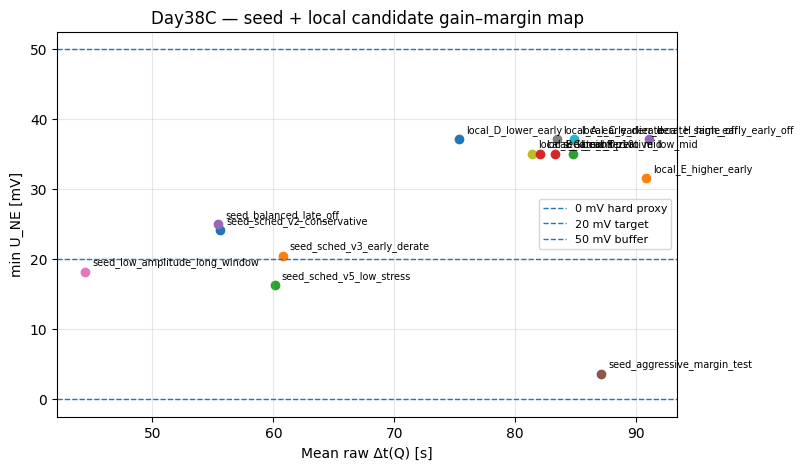

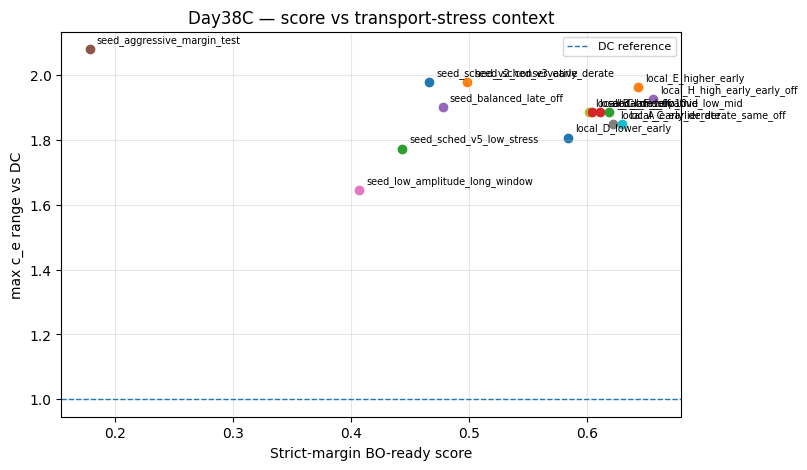

In [17]:
# Cell 16 — Plot local expansion gain–margin trade-off（绘制局部扩展收益-余量权衡）

plot_df = combined_strict_ranking_df.copy()
plot_df = plot_df[plot_df["policy_id"] != "DC03_reference"].copy()

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in plot_df.iterrows():
    ax.scatter(row["delta_t_raw_mean_s"], row["min_U_NE_mV"])
    ax.annotate(
        row["policy_id"],
        (row["delta_t_raw_mean_s"], row["min_U_NE_mV"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=7,
    )

ax.axhline(0.0, linestyle="--", linewidth=1, label="0 mV hard proxy")
ax.axhline(MARGIN_TARGET_MV, linestyle="--", linewidth=1, label=f"{MARGIN_TARGET_MV:.0f} mV target")
ax.axhline(PLATING_MARGIN_BUFFER_MV, linestyle="--", linewidth=1, label="50 mV buffer")
ax.set_xlabel("Mean raw Δt(Q) [s]")
ax.set_ylabel("min U_NE [mV]")
ax.set_title("Day38C — seed + local candidate gain–margin map")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in plot_df.iterrows():
    ax.scatter(row["bo_ready_score_strict_margin"], row["max_c_e_range_vs_DC"])
    ax.annotate(
        row["policy_id"],
        (row["bo_ready_score_strict_margin"], row["max_c_e_range_vs_DC"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=7,
    )

ax.axhline(1.0, linestyle="--", linewidth=1, label="DC reference")
ax.set_xlabel("Strict-margin BO-ready score")
ax.set_ylabel("max c_e range vs DC")
ax.set_title("Day38C — score vs transport-stress context")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()

In [18]:
# Cell 17 — Day38 final synthesis table（Day38最终综合表）

# Use the combined strict ranking from Cell 15.
final_df = combined_strict_ranking_df.copy()

def recommendation_class_day38(row):
    pid = row["policy_id"]

    if pid == "local_H_high_early_early_off":
        return "primary_fixed_frequency_candidate"
    if pid == "local_C_earlier_derate_same_off":
        return "secondary_conservative_candidate"
    if pid == "local_E_higher_early":
        return "high_gain_stress_sensitive_candidate"
    if pid == "local_A_early_derate":
        return "robust_local_candidate"
    if pid == "local_D_lower_early":
        return "lower_transport_candidate"
    if pid == "seed_aggressive_margin_test":
        return "deprioritize_low_margin"
    if "seed_sched_v2" in pid:
        return "day35_primary_reference"
    if "seed_sched_v3" in pid:
        return "day35_balanced_reference"
    if "seed_sched_v5" in pid:
        return "day35_low_stress_reference"
    if pid == "seed_conservative_low_mid":
        return "day38_initial_best_seed"
    return "supporting_candidate"


def recommendation_rationale_day38(row):
    pid = row["policy_id"]

    if pid == "local_H_high_early_early_off":
        return (
            "Best fixed-frequency amplitude/window candidate in Day38C. "
            "Combines high early AC with earlier derating and earlier AC-off, "
            "retaining high raw gain while keeping min U_NE well above 20 mV."
        )

    if pid == "local_C_earlier_derate_same_off":
        return (
            "More conservative local candidate. Lower raw gain than local_H but similar margin "
            "and lower electrolyte-gradient stress; useful as robustness-oriented alternative."
        )

    if pid == "local_E_higher_early":
        return (
            "High-gain candidate with lower margin and stronger overpotential / transport stress. "
            "Keep as aggressive reference, not primary robust candidate."
        )

    if pid == "local_A_early_derate":
        return (
            "Early derating and early AC-off candidate with strong margin; useful local benchmark."
        )

    if pid == "local_D_lower_early":
        return (
            "Lower early amplitude reduces transport stress but sacrifices raw timing gain."
        )

    if pid == "seed_aggressive_margin_test":
        return (
            "High raw gain but too close to the 0 mV hard-margin proxy; deprioritized by strict-margin score."
        )

    if pid == "seed_conservative_low_mid":
        return (
            "Initial best Day38 seed before local expansion; improved upon by local_H and local_C."
        )

    if "seed_sched" in pid:
        return (
            "Day35 reference candidate retained for traceability; outperformed by Day38 local expansion."
        )

    return "Supporting candidate in fixed-frequency local search."

final_df["day38_recommendation_class"] = final_df.apply(recommendation_class_day38, axis=1)
final_df["day38_recommendation_rationale"] = final_df.apply(recommendation_rationale_day38, axis=1)

# Put most important rows first.
recommendation_order = {
    "primary_fixed_frequency_candidate": 0,
    "secondary_conservative_candidate": 1,
    "high_gain_stress_sensitive_candidate": 2,
    "robust_local_candidate": 3,
    "day38_initial_best_seed": 4,
    "lower_transport_candidate": 5,
    "day35_primary_reference": 6,
    "day35_balanced_reference": 7,
    "day35_low_stress_reference": 8,
    "supporting_candidate": 9,
    "deprioritize_low_margin": 10,
}

final_df["day38_recommendation_order"] = (
    final_df["day38_recommendation_class"].map(recommendation_order).fillna(99)
)

day38_final_synthesis_df = final_df.sort_values(
    ["day38_recommendation_order", "bo_ready_score_strict_margin"],
    ascending=[True, False],
).reset_index(drop=True)

out = DATA_DIR / "day38_final_policy_synthesis.csv"
day38_final_synthesis_df.to_csv(out, index=False)

print("[OK] saved Day38 final policy synthesis:", out)

display_cols = [
    "source_group",
    "policy_id",
    "day38_recommendation_class",
    "early_ac_c",
    "mid_ac_c",
    "qfrac_derate",
    "qfrac_ac_off",
    "delta_t_raw_mean_s",
    "delta_t_geom_mean_s",
    "delta_t_resid_mean_s",
    "dt_resid_class",
    "min_U_NE_mV",
    "fraction_time_below_0mV",
    "max_c_e_range_vs_DC",
    "surface_range_at_min_vs_DC",
    "abs_eta_n_at_min_vs_DC",
    "bo_ready_score_strict_margin",
    "constraint_verdict",
    "strict_candidate_class",
    "day38_recommendation_rationale",
]

display(day38_final_synthesis_df[display_cols])


# Recommended candidates for future BO / Day39.
day38_recommended_candidates_df = day38_final_synthesis_df[
    day38_final_synthesis_df["day38_recommendation_class"].isin([
        "primary_fixed_frequency_candidate",
        "secondary_conservative_candidate",
        "high_gain_stress_sensitive_candidate",
        "robust_local_candidate",
        "lower_transport_candidate",
    ])
].copy()

out = DATA_DIR / "day38_recommended_fixed_frequency_candidates.csv"
day38_recommended_candidates_df.to_csv(out, index=False)

print("[OK] saved recommended fixed-frequency candidates:", out)
display(
    day38_recommended_candidates_df[
        [
            "policy_id",
            "day38_recommendation_class",
            "early_ac_c",
            "mid_ac_c",
            "qfrac_derate",
            "qfrac_ac_off",
            "delta_t_raw_mean_s",
            "min_U_NE_mV",
            "max_c_e_range_vs_DC",
            "bo_ready_score_strict_margin",
        ]
    ]
)


# Final claim / boundary summary.
day38_claim_rows = [
    {
        "claim": "BO-ready evaluator contract was established",
        "evidence": "evaluate_policy_theta maps policy parameters to timing, U_NE, microstate, constraint, and score outputs.",
        "verdict": "supported",
        "boundary": "Evaluator uses Chen2020 / DFN / isothermal / fixed 1.5τ_set frequency.",
    },
    {
        "claim": "Fixed-frequency amplitude/window policy can outperform Day35 hand-designed v2/v3 seeds",
        "evidence": "local_H and local_C outperform Day35 seeds in strict-margin score.",
        "verdict": "supported",
        "boundary": "Only local deterministic expansion, not full Bayesian optimization.",
    },
    {
        "claim": "local_H is the current primary fixed-frequency candidate",
        "evidence": "local_H has the highest strict-margin score with Δt_raw≈91 s and min U_NE≈37 mV.",
        "verdict": "supported_as_current_screen_result",
        "boundary": "Needs robustness checks under transport sensitivity, thermal, aging, and cross-parameter transfer.",
    },
    {
        "claim": "Day38 proves global optimality",
        "evidence": "Only seed plus local deterministic expansion was run.",
        "verdict": "not_supported",
        "boundary": "A true BO loop or broader search is required.",
    },
    {
        "claim": "Day38 includes SOC-dependent tau-rebased frequency scheduling",
        "evidence": "Frequency remains fixed at 1.5τ_set throughout Day38.",
        "verdict": "not_supported",
        "boundary": "SOC-dependent τ₂-rebased frequency scheduling is deferred to Day39.",
    },
    {
        "claim": "Day38 implements MPC",
        "evidence": "All policies are open-loop prescribed-current schedules.",
        "verdict": "not_supported",
        "boundary": "MPC-ready formulation is deferred to later notebook.",
    },
]

day38_final_claim_boundary_df = pd.DataFrame(day38_claim_rows)

out = DATA_DIR / "day38_final_claim_boundary.csv"
day38_final_claim_boundary_df.to_csv(out, index=False)

print("[OK] saved Day38 final claim boundary:", out)
display(day38_final_claim_boundary_df)


[OK] saved Day38 final policy synthesis: /Users/louislu/pybamm-dcac-superimposed/data/day38_final_policy_synthesis.csv


,source_group,policy_id,day38_recommendation_class,early_ac_c,mid_ac_c,qfrac_derate,qfrac_ac_off,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,dt_resid_class,min_U_NE_mV,fraction_time_below_0mV,max_c_e_range_vs_DC,surface_range_at_min_vs_DC,abs_eta_n_at_min_vs_DC,bo_ready_score_strict_margin,constraint_verdict,strict_candidate_class,day38_recommendation_rationale
0,local_expansion,local_H_high_early_early_off,primary_fixed_frequency_candidate,0.38,0.05,0.62,0.77,91.049844,91.069739,-0.019895,geometry_dominated,37.151324,0.0,1.927187,1.062431,1.002093,0.655716,feasible_near_boundary,primary_bo_seed_candidate,Best fixed-frequency amplitude/window candidat...
1,local_expansion,local_C_earlier_derate_same_off,secondary_conservative_candidate,0.35,0.05,0.62,0.78,84.884320,84.900044,-0.015724,geometry_dominated,37.166602,0.0,1.848630,1.055321,1.001845,0.629178,feasible_near_boundary,primary_bo_seed_candidate,More conservative local candidate. Lower raw g...
2,local_expansion,local_E_higher_early,high_gain_stress_sensitive_candidate,0.38,0.05,0.65,0.78,90.806643,90.825860,-0.019218,geometry_dominated,31.542877,0.0,1.963723,0.929388,1.511744,0.643053,feasible_near_boundary,primary_bo_seed_candidate,High-gain candidate with lower margin and stro...
3,local_expansion,local_A_early_derate,robust_local_candidate,0.35,0.05,0.62,0.77,83.424368,83.440471,-0.016103,geometry_dominated,37.168775,0.0,1.848630,1.054255,1.001809,0.621932,feasible_near_boundary,primary_bo_seed_candidate,Early derating and early AC-off candidate with...
4,seed,seed_conservative_low_mid,day38_initial_best_seed,0.35,0.05,0.65,0.78,83.315438,83.331054,-0.015616,geometry_dominated,35.078052,0.0,1.885933,0.910451,1.460247,0.610774,feasible_near_boundary,primary_bo_seed_candidate,Initial best Day38 seed before local expansion...
5,local_expansion,local_D_lower_early,lower_transport_candidate,0.32,0.05,0.65,0.78,75.389356,75.402645,-0.013289,geometry_dominated,37.168982,0.0,1.807414,1.053665,1.001806,0.583848,feasible_near_boundary,primary_bo_seed_candidate,Lower early amplitude reduces transport stress...
6,seed,seed_sched_v2_conservative,day35_primary_reference,0.38,0.10,0.70,0.80,55.576168,55.593112,-0.016943,geometry_dominated,24.160262,0.0,1.978691,0.806120,1.520948,0.465923,feasible_near_boundary,secondary_bo_seed_candidate,Day35 reference candidate retained for traceab...
7,seed,seed_sched_v3_early_derate,day35_balanced_reference,0.38,0.20,0.70,0.85,60.765309,60.782699,-0.017390,geometry_dominated,20.499177,0.0,1.978691,0.890900,1.265529,0.498254,feasible_near_boundary,secondary_bo_seed_candidate,Day35 reference candidate retained for traceab...
8,seed,seed_sched_v5_low_stress,day35_low_stress_reference,0.30,0.10,0.75,0.85,60.098551,60.110238,-0.011687,geometry_dominated,16.256867,0.0,1.773576,0.672516,1.396201,0.442860,feasible_near_boundary,acceptable_but_low_margin,Day35 reference candidate retained for traceab...
9,local_expansion,local_F_zero_mid,supporting_candidate,0.35,0.00,0.65,0.78,84.792674,84.808841,-0.016167,geometry_dominated,35.078052,0.0,1.885933,0.910451,1.460247,0.618161,feasible_near_boundary,primary_bo_seed_candidate,Supporting candidate in fixed-frequency local ...


[OK] saved recommended fixed-frequency candidates: /Users/louislu/pybamm-dcac-superimposed/data/day38_recommended_fixed_frequency_candidates.csv


,policy_id,day38_recommendation_class,early_ac_c,mid_ac_c,qfrac_derate,qfrac_ac_off,delta_t_raw_mean_s,min_U_NE_mV,max_c_e_range_vs_DC,bo_ready_score_strict_margin
0,local_H_high_early_early_off,primary_fixed_frequency_candidate,0.38,0.05,0.62,0.77,91.049844,37.151324,1.927187,0.655716
1,local_C_earlier_derate_same_off,secondary_conservative_candidate,0.35,0.05,0.62,0.78,84.884320,37.166602,1.848630,0.629178
2,local_E_higher_early,high_gain_stress_sensitive_candidate,0.38,0.05,0.65,0.78,90.806643,31.542877,1.963723,0.643053
3,local_A_early_derate,robust_local_candidate,0.35,0.05,0.62,0.77,83.424368,37.168775,1.848630,0.621932
5,local_D_lower_early,lower_transport_candidate,0.32,0.05,0.65,0.78,75.389356,37.168982,1.807414,0.583848


[OK] saved Day38 final claim boundary: /Users/louislu/pybamm-dcac-superimposed/data/day38_final_claim_boundary.csv


,claim,evidence,verdict,boundary
0,BO-ready evaluator contract was established,evaluate_policy_theta maps policy parameters t...,supported,Evaluator uses Chen2020 / DFN / isothermal / f...
1,Fixed-frequency amplitude/window policy can ou...,local_H and local_C outperform Day35 seeds in ...,supported,"Only local deterministic expansion, not full B..."
2,local_H is the current primary fixed-frequency...,local_H has the highest strict-margin score wi...,supported_as_current_screen_result,Needs robustness checks under transport sensit...
3,Day38 proves global optimality,Only seed plus local deterministic expansion w...,not_supported,A true BO loop or broader search is required.
4,Day38 includes SOC-dependent tau-rebased frequ...,Frequency remains fixed at 1.5τ_set throughout...,not_supported,SOC-dependent τ₂-rebased frequency scheduling ...
5,Day38 implements MPC,All policies are open-loop prescribed-current ...,not_supported,MPC-ready formulation is deferred to later not...


## Final closure — Notebook 38

Notebook 38 established a BO-ready fixed-frequency state-aware DC–AC policy evaluator.

The project context after Day37 is no longer to prove non-geometric terminal-Q acceleration. The supported direction is admissible DC–AC waveform optimization under geometry, microstate, U_NE margin, and future thermal / aging constraints.

Day38 therefore defined the first optimization layer:

```text
A_AC(Q) at fixed frequency
```

with:

```text
f = 1 / (2π · 1.5τ_set)
```

and policy variables:

- `early_ac_c`
- `mid_ac_c`
- `qfrac_derate`
- `qfrac_ac_off`

Day38A defined the BO-ready search space and seed-policy table. Day38B implemented the PyBaMM evaluator contract:

```text
θ = {early_ac_c, mid_ac_c, qfrac_derate, qfrac_ac_off}
→ prescribed-current waveform
→ PyBaMM DFN run
→ timing / U_NE / microstate metrics
→ constraint verdict
→ scalar score
```

Day38C then performed a small deterministic local expansion around the best seed candidate. This was not full Bayesian optimization; it was a local seed-improvement screen.

The initial best seed from Day38B was:

```text
seed_conservative_low_mid
early_ac_c = 0.35
mid_ac_c = 0.05
qfrac_derate = 0.65
qfrac_ac_off = 0.78
```

Its result was approximately:

```text
Δt_raw_mean ≈ 83.3 s
min_U_NE ≈ +35.1 mV
```

The local expansion identified a stronger fixed-frequency candidate:

```text
local_H_high_early_early_off
early_ac_c = 0.38
mid_ac_c = 0.05
qfrac_derate = 0.62
qfrac_ac_off = 0.77
```

Its result was approximately:

```text
Δt_raw_mean ≈ 91.0 s
min_U_NE ≈ +37.2 mV
max_c_e_range_vs_DC ≈ 1.93
```

This candidate became the current primary fixed-frequency amplitude/window candidate.

A more conservative alternative is:

```text
local_C_earlier_derate_same_off
early_ac_c = 0.35
mid_ac_c = 0.05
qfrac_derate = 0.62
qfrac_ac_off = 0.78
```

Its result was approximately:

```text
Δt_raw_mean ≈ 84.9 s
min_U_NE ≈ +37.2 mV
max_c_e_range_vs_DC ≈ 1.85
```

The main design insight is:

> Higher early AC can be useful if derating and AC-off occur early enough to avoid the high-Q / voltage-boundary risk region.

This is consistent with the Day33 risk-localization result.

All Day38 policies remain geometry-dominated in timing interpretation. Day38 did not re-establish non-geometric terminal-Q acceleration.

Correct conclusion wording:

> Day38 established a BO-ready evaluator for fixed-frequency amplitude/window DC–AC policies. A local deterministic expansion identified `local_H_high_early_early_off` as the strongest current fixed-frequency candidate, improving the gain–margin trade-off relative to the Day35 seed policies. This is not a globally optimized controller and not MPC; it is a BO-ready policy-evaluation layer.

Interpretation boundary:

- Day38 uses fixed `1.5τ_set` frequency.
- Day38 optimizes only amplitude and activation-window parameters.
- Day38 does not include SOC-dependent τ₂-rebased frequency scheduling.
- Day38 does not implement Bayesian optimization yet; it defines the evaluator and performs a local deterministic expansion.
- Day38 does not implement MPC.
- Day38 remains Chen2020 / DFN / isothermal.
- Thermal, aging, cross-parameter, and experimental transfer remain deferred.

Next step:

Day39 should introduce SOC / Q-segmented τ₂-rebased frequency scheduling:

```text
f(Q) = 1 / (2π · k · τ₂(Q))
```

Day40 can then combine amplitude/window optimization with frequency scheduling:

```text
A_AC(Q) + f(Q)
```

A later notebook can formulate the MPC-ready state / control / constraint structure.
